# KT_Predictions vs KT - Wilcoxon tests

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon, skew
import pandas as pd 
import numpy as np 

results = pd.read_csv("../package_metadata/results_all.csv") 
explainers = results["explainer_total"].unique() 
tasks = results["task"].unique() 
models = results["model_name"].unique() 
metrics = [ 
    ("mae", True),
    ("mae_std", True), 
    ("top_k", False), 
    ("top_k_std", True), 
] 
methods = ["kt_gaussian", "kt_predictions"]

def compare_two_methods_wilcoxon(
    df,
    metric,
    methods,
    lower_is_better=True,
    alpha=0.05
):
    assert len(methods) == 2, "Exactly two methods must be provided."

    # --- A. Aggregation ---
    if metric.endswith("_std"):
        base_metric = metric.replace("_std", "")
        if base_metric.endswith("_"):
            base_metric = base_metric[:-1]

        df_agg = (
            df.groupby(
                ["dataset_name", "compression_coefficient", "method_total"]
            )[base_metric]
            .std()
            .reset_index()
            .rename(columns={base_metric: metric})
        )
    else:
        df_agg = (
            df.groupby(
                ["dataset_name", "compression_coefficient", "method_total"]
            )[metric]
            .mean()
            .reset_index()
        )

    # --- B. Pivot (paired blocks) ---
    pivot = df_agg.pivot_table(
        index=["dataset_name", "compression_coefficient"],
        columns="method_total",
        values=metric
    ).dropna()

    m1, m2 = methods
    x = pivot[m1]
    y = pivot[m2]

    # --- C. Wilcoxon test ---
    stat, p_value = wilcoxon(x, y, alternative="two-sided")

    # --- D. Effect diagnostics ---
    diff = y - x
    mean_diff = diff.mean()
    median_diff = diff.median()
    skewness = skew(diff)

    # --- E. Winner determination based on mean_diff shift ---
    if p_value < alpha:
        if lower_is_better:
            winner = m2 if mean_diff < 0 else m1
        else:
            winner = m2 if mean_diff > 0 else m1
    else:
        winner = "No significant difference"

    # --- F. Summary ---
    summary = pd.DataFrame([{
        "Metric": metric,
        "Method 1": m1,
        "Method 2": m2,
        "Mean diff (m2 - m1)": mean_diff,
        "Median diff": median_diff,
        "Wilcoxon stat": stat,
        "p-value": p_value,
        "Significant": "Yes" if p_value < alpha else "No",
        "Skewness (diff)": skewness,
        "Winner": winner,
        "N blocks": len(pivot)
    }])

    return summary

/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_27749/1817993539.py:7: DtypeWarning: Columns (30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  results = pd.read_csv("../package_metadata/results_all.csv")


In [2]:
for explainer in explainers:
    for task in tasks:
        for model in models:

            df_cfg = results[
                (results["explainer_total"] == explainer) &
                (results["task"] == task) &
                (results["model_name"] == model) &
                (results["method_total"].isin(methods))
            ].copy()

            if df_cfg.empty:
                continue

            print("\n" + "=" * 90)
            print(f"EXPLAINER: {explainer} | TASK: {task} | MODEL: {model}")
            print("=" * 90)

            for metric, lower_is_better in metrics:
                try:
                    summary = compare_two_methods_wilcoxon(
                        df=df_cfg,
                        metric=metric,
                        methods=methods,
                        lower_is_better=lower_is_better
                    )

                    row = summary.iloc[0]

                    p_val_sci = f"{row['p-value']:.1e}"

                    print(f"\nMetric: {row['Metric']}")
                    print("-" * 50)
                    print(f"Methods compared : {row['Method 1']} vs {row['Method 2']}")
                    print(f"N blocks         : {row['N blocks']}")
                    print(f"Mean diff (m2-m1): {row['Mean diff (m2 - m1)']:.6f}")
                    print(f"Median diff      : {row['Median diff']:.6f}")
                    print(f"Skewness         : {row['Skewness (diff)']:.2f}")
                    print(f"Wilcoxon stat    : {row['Wilcoxon stat']:.4f}")
                    print(f"p-value          : {p_val_sci}")
                    print(f"Significant      : {row['Significant']}")
                    print(f"Winner           : {row['Winner']}")

                except Exception as e:
                    print(f"\nMetric: {metric}")
                    print(f"  Skipped due to error: {e}")



EXPLAINER: expected_gradients | TASK: classification | MODEL: nn

Metric: mae
--------------------------------------------------
Methods compared : kt_gaussian vs kt_predictions
N blocks         : 50
Mean diff (m2-m1): -0.000369
Median diff      : 0.000000
Skewness         : -4.59
Wilcoxon stat    : 429.0000
p-value          : 9.8e-01
Significant      : No
Winner           : No significant difference

Metric: mae_std
--------------------------------------------------
Methods compared : kt_gaussian vs kt_predictions
N blocks         : 50
Mean diff (m2-m1): -0.000296
Median diff      : 0.000000
Skewness         : -3.48
Wilcoxon stat    : 246.0000
p-value          : 1.7e-01
Significant      : No
Winner           : No significant difference

Metric: top_k
--------------------------------------------------
Methods compared : kt_gaussian vs kt_predictions
N blocks         : 50
Mean diff (m2-m1): -0.001408
Median diff      : 0.000000
Skewness         : -0.44
Wilcoxon stat    : 405.0000
p-val

# 3 Kernels

In [3]:
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare

# Methods to compare
methods_kernels = ["kt_matern", "kt_inverse_multiquadric", "kt_gaussian"]

def compare_kernels_friedman(
    df,
    metric,
    methods,
    lower_is_better=True,
    alpha=0.05
):
    # --- A. Aggregation ---
    if metric.endswith("_std"):
        base_metric = metric.replace("_std", "").rstrip("_")
        df_agg = df.groupby(["dataset_name", "compression_coefficient", "method_total"])[base_metric].std().reset_index().rename(columns={base_metric: metric})
    else:
        df_agg = df.groupby(["dataset_name", "compression_coefficient", "method_total"])[metric].mean().reset_index()

    # --- B. Pivot ---
    pivot = df_agg.pivot_table(
        index=["dataset_name", "compression_coefficient"],
        columns="method_total",
        values=metric
    ).dropna()

    if not all(m in pivot.columns for m in methods):
        raise ValueError("Not all methods found in pivot table.")

    # --- C. Friedman test ---
    # Comparing the three columns directly
    stat, p_value = friedmanchisquare(
            pivot[methods[0]], 
            pivot[methods[1]], 
            pivot[methods[2]]
        )

    # --- D. Determine the winner via Average Ranks ---
    # We rank each row: 1 is the best, 3 is the worst.
    # If lower_is_better=True (MAE), the smallest value gets rank 1.
    # If lower_is_better=False (Top-K), the largest value gets rank 1.
    ranks = pivot[methods].rank(axis=1, ascending=lower_is_better)
    
    # Calculate the average rank for each method across all blocks
    mean_ranks = ranks.mean()
    
    if p_value < alpha:
        # The winner is the method with the LOWEST average rank (closest to 1st place)
        winner = mean_ranks.idxmin()
        significance = "Yes"
    else:
        winner = "No sign. diff."
        significance = "No"

    # Mapping internal names to clean display names
    short_names = {
        "kt_matern": "Matérn",
        "kt_inverse_multiquadric": "Inverse Multiquadric",
        "kt_gaussian": "Gaussian"
    }
    
    winner_code = short_names.get(winner, winner)

    summary = pd.DataFrame([{
        "Metric": metric,
        "Friedman stat": stat,
        "p-value": p_value,
        "Significant": significance,
        "Winner": winner_code,
        "Winner_Full": winner,
        "N blocks": len(pivot),
        "Mean Ranks": mean_ranks.to_dict()
    }])

    return summary

# --- Run cycle ---
for explainer in explainers:
    for task in tasks:
        for model in models:
            df_cfg = results[
                (results["explainer_total"] == explainer) &
                (results["task"] == task) &
                (results["model_name"] == model) &
                (results["method_total"].isin(methods_kernels))
            ].copy()

            if df_cfg.empty or df_cfg["method_total"].nunique() < 3:
                continue

            print(f"\n[FRIEDMAN] {explainer} | {task} | {model}")
            
            for metric, lower_is_better in metrics:
                try:
                    summary = compare_kernels_friedman(df_cfg, metric, methods_kernels, lower_is_better)
                    row = summary.iloc[0]
                    
                    res_str = f"{row['Winner']}"
                    print(f"{metric:12}: F: {res_str} (p={row['p-value']:.1e})")
                except Exception as e:
                    print(f"{metric:12}: Error {e}")


[FRIEDMAN] expected_gradients | classification | nn
mae         : F: Inverse Multiquadric (p=8.3e-05)
mae_std     : F: Matérn (p=1.8e-04)
top_k       : F: Inverse Multiquadric (p=2.9e-02)
top_k_std   : F: No sign. diff. (p=5.0e-01)

[FRIEDMAN] expected_gradients | regression | nn
mae         : F: No sign. diff. (p=1.6e-01)
mae_std     : F: No sign. diff. (p=2.8e-01)
top_k       : F: No sign. diff. (p=2.1e-01)
top_k_std   : F: No sign. diff. (p=2.0e-01)

[FRIEDMAN] sage_permutation | classification | nn
mae         : F: No sign. diff. (p=7.8e-01)
mae_std     : F: Matérn (p=2.2e-02)
top_k       : F: No sign. diff. (p=1.7e-01)
top_k_std   : F: No sign. diff. (p=5.9e-01)

[FRIEDMAN] sage_permutation | classification | xgboost
mae         : F: No sign. diff. (p=1.9e-01)
mae_std     : F: No sign. diff. (p=5.5e-02)
top_k       : F: No sign. diff. (p=3.8e-01)
top_k_std   : F: No sign. diff. (p=3.0e-01)

[FRIEDMAN] sage_permutation | regression | nn
mae         : F: No sign. diff. (p=5.6e-01)


In [4]:
from scipy.stats import wilcoxon
from itertools import combinations

# Mapping for clean output
short_names = {
    "kt_matern": "M",
    "kt_inverse_multiquadric": "IMQ",
    "kt_gaussian": "G"
}

def compare_kernels_sorted_pairs(
    df,
    metric,
    methods,
    lower_is_better=True,
    alpha=0.05
):
    # --- A & B: Aggregation and Pivot ---
    if metric.endswith("_std"):
        base_metric = metric.replace("_std", "").rstrip("_")
        df_agg = df.groupby(["dataset_name", "compression_coefficient", "method_total"])[base_metric].std().reset_index().rename(columns={base_metric: metric})
    else:
        df_agg = df.groupby(["dataset_name", "compression_coefficient", "method_total"])[metric].mean().reset_index()

    pivot = df_agg.pivot_table(
        index=["dataset_name", "compression_coefficient"],
        columns="method_total",
        values=metric
    ).dropna()

    adj_alpha = alpha / 3
    significant_pairs = []
    equal_pairs = []

    # --- C. Compare every combination (3 pairs) ---
    for m1_key, m2_key in combinations(methods, 2):
        s1 = pivot[m1_key]
        s2 = pivot[m2_key]
        
        _, p_val = wilcoxon(s1, s2)
        
        m1_val = s1.mean()
        m2_val = s2.mean()
        
        name1 = short_names[m1_key]
        name2 = short_names[m2_key]

        if p_val < adj_alpha:
            # Determine winner to ensure the notation is always "Winner > Loser"
            if lower_is_better:
                # For MAE, smaller mean is the winner
                if m1_val < m2_val:
                    significant_pairs.append(f"{name1} > {name2}")
                else:
                    significant_pairs.append(f"{name2} > {name1}")
            else:
                # For Top-K, larger mean is the winner
                if m1_val > m2_val:
                    significant_pairs.append(f"{name1} > {name2}")
                else:
                    significant_pairs.append(f"{name2} > {name1}")
        else:
            equal_pairs.append(f"{name1} = {name2}")

    # Combine: Significant pairs first, then Equal pairs
    all_results = significant_pairs + equal_pairs
    return ", ".join(all_results)

# --- Run cycle ---
for explainer in explainers:
    for task in tasks:
        for model in models:
            df_cfg = results[
                (results["explainer_total"] == explainer) &
                (results["task"] == task) &
                (results["model_name"] == model) &
                (results["method_total"].isin(methods_kernels))
            ].copy()

            if df_cfg.empty or df_cfg["method_total"].nunique() < 3:
                continue

            print(f"\n[WILCOXON SORTED] {explainer} | {task} | {model}")
            
            for metric, lower_is_better in metrics:
                try:
                    res_str = compare_kernels_sorted_pairs(
                        df_cfg, metric, methods_kernels, lower_is_better
                    )
                    print(f"{metric:12} W: {res_str}")
                except Exception as e:
                    print(f"{metric:12}: Error {e}")


[WILCOXON SORTED] expected_gradients | classification | nn
mae          W: IMQ > G, M = IMQ, M = G
mae_std      W: M > G, IMQ > G, M = IMQ
top_k        W: M = IMQ, M = G, IMQ = G
top_k_std    W: M = IMQ, M = G, IMQ = G

[WILCOXON SORTED] expected_gradients | regression | nn
mae          W: M = IMQ, M = G, IMQ = G
mae_std      W: M = IMQ, M = G, IMQ = G
top_k        W: M = IMQ, M = G, IMQ = G
top_k_std    W: M = IMQ, M = G, IMQ = G

[WILCOXON SORTED] sage_permutation | classification | nn
mae          W: M = IMQ, M = G, IMQ = G
mae_std      W: M = IMQ, M = G, IMQ = G
top_k        W: M = IMQ, M = G, IMQ = G
top_k_std    W: M = IMQ, M = G, IMQ = G

[WILCOXON SORTED] sage_permutation | classification | xgboost
mae          W: M = IMQ, M = G, IMQ = G
mae_std      W: M = IMQ, M = G, IMQ = G
top_k        W: M = IMQ, M = G, IMQ = G
top_k_std    W: M = IMQ, M = G, IMQ = G

[WILCOXON SORTED] sage_permutation | regression | nn
mae          W: M = IMQ, M = G, IMQ = G
mae_std      W: M = IMQ, M = 

## Figures 22

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# -----------------------------
# CONFIG
# -----------------------------
METRIC = "mae"
ALPHA = 0.05

# -----------------------------
# BLOCK-LEVEL WILCOXON TABLE
# -----------------------------
def block_wilcoxon_table(
    results: pd.DataFrame,
    metric: str,
    method_1: str,
    method_2: str,
    alpha: float = 0.05,
) -> pd.DataFrame:
    df = results[results["method_total"].isin([method_1, method_2])].copy()

    group_cols = [
        "dataset_name",
        "compression_coefficient",
        "task",
        "model_name",
        "explainer_total",
    ]
    rows = []

    for key, g in df.groupby(group_cols):
        a = g[g["method_total"] == method_1][metric].dropna().to_numpy(dtype=float)
        b = g[g["method_total"] == method_2][metric].dropna().to_numpy(dtype=float)

        n = min(len(a), len(b))
        if n < 2:
            continue

        a = a[:n]
        b = b[:n]

        stat, p = wilcoxon(a, b, alternative="two-sided", zero_method="wilcox")

        diff = b - a  # (method_2 - method_1)
        mean_diff = float(np.mean(diff))

        if p < alpha:
            winner = method_2 if mean_diff < 0 else method_1  # lower metric is better (MAE)
            significant = True
        else:
            winner = "No significant difference"
            significant = False

        rows.append({
            "dataset_name": key[0],
            "compression_coefficient": key[1],
            "task": key[2],
            "model_name": key[3],
            "explainer_total": key[4],
            "n_pairs": int(n),
            "p_value": float(p),
            "significant": significant,
            "mean_diff (m2 - m1)": mean_diff,
            "winner": winner,
        })

    out = pd.DataFrame(rows)

    if not out.empty:
        out["compression_coefficient"] = pd.to_numeric(out["compression_coefficient"], errors="coerce")
        out = out.dropna(subset=["compression_coefficient"])
        out = out.sort_values(
            ["task", "explainer_total", "model_name", "dataset_name", "compression_coefficient"]
        ).reset_index(drop=True)

    return out

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_13564/1224770351.py:79: DtypeWarning: Columns (30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  results = pd.read_csv("../package_metadata/results_all.csv")
/opt/anaconda3/envs/cte/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


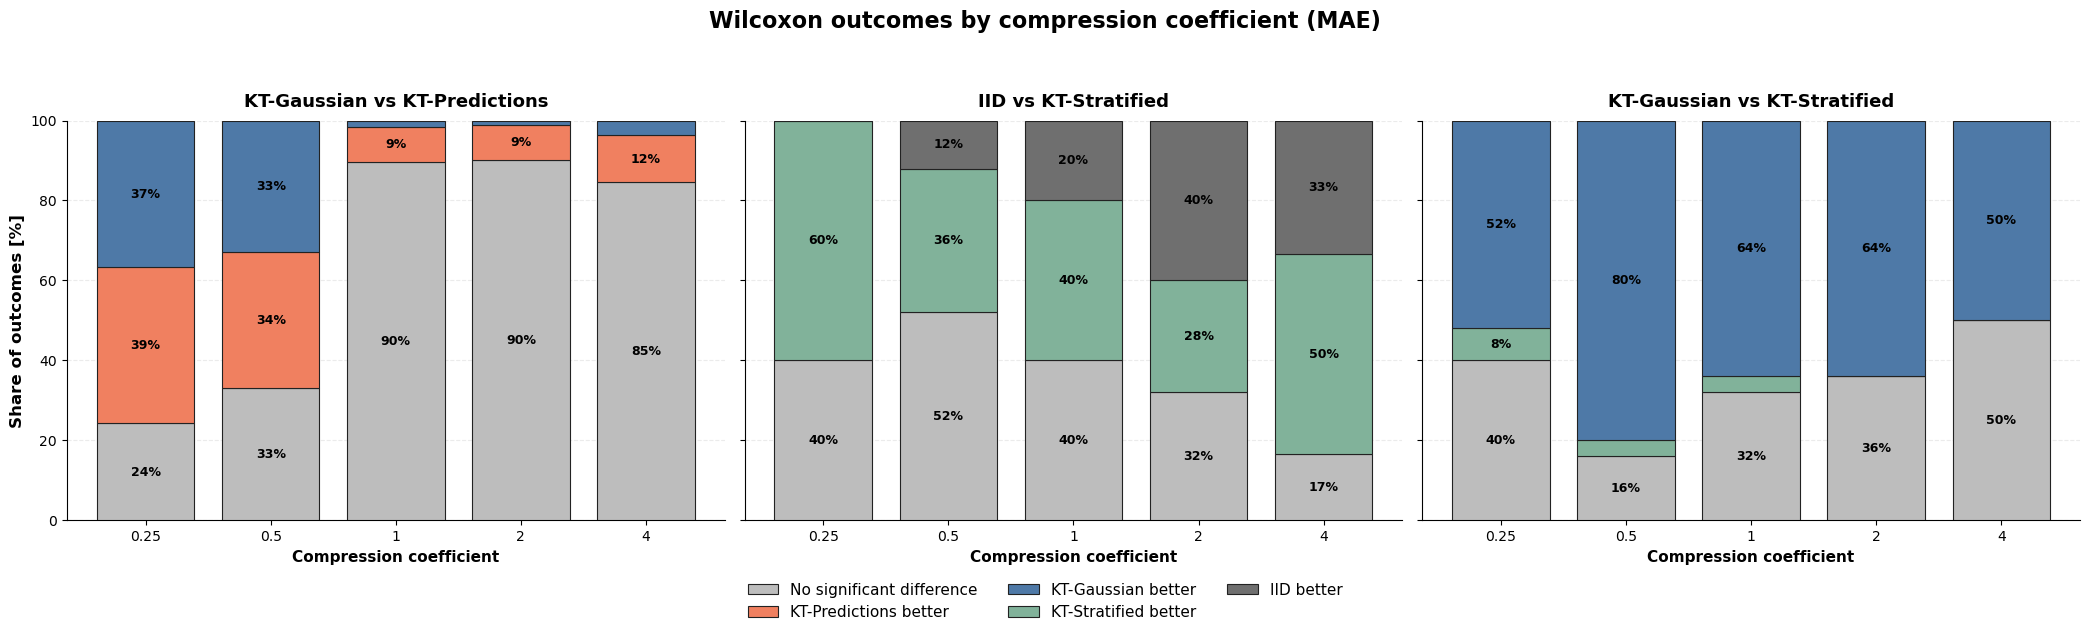

In [5]:
import os

def plot_wilcoxon_stacked(
    table: pd.DataFrame,
    method_1: str,
    method_2: str,
    ax,
    title: str,
    colors: dict,
    labels_pretty: dict,
):
    df = table.copy()
    df["compression_coefficient"] = pd.to_numeric(df["compression_coefficient"], errors="coerce")
    df = df.dropna(subset=["compression_coefficient", "winner"])

    cc_order = sorted(df["compression_coefficient"].unique())
    cc_labels = [f"{cc:g}" for cc in cc_order]

    winner_order = ["No significant difference", method_2, method_1]

    dist = (
        df.groupby(["compression_coefficient", "winner"])
          .size()
          .unstack(fill_value=0)
          .reindex(index=cc_order, columns=winner_order, fill_value=0)
    )

    pct = dist.div(dist.sum(axis=1), axis=0) * 100.0

    x = np.arange(len(cc_order))
    bottom = np.zeros(len(cc_order))

    for cat in winner_order:
        vals = pct[cat].values

        ax.bar(
            x,
            vals,
            bottom=bottom,
            width=0.78,
            color=colors[cat],
            edgecolor="#222222",
            linewidth=0.8,
            label=labels_pretty[cat],
            zorder=3,
        )

        for i, v in enumerate(vals):
            if v >= 6:
                ax.text(
                    x[i],
                    bottom[i] + v / 2,
                    f"{v:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    fontweight="bold",
                    color="black",
                    zorder=4,
                )

        bottom += vals

    ax.set_ylim(0, 100)
    ax.set_xticks(x)
    ax.set_xticklabels(cc_labels, fontsize=10)
    ax.set_xlabel("Compression coefficient", fontsize=11, fontweight="bold")
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)

    ax.grid(axis="y", linestyle="--", alpha=0.25, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# -----------------------------
# RUN (FULL PIPELINE)
# -----------------------------
# Load your raw results
results = pd.read_csv("../package_metadata/results_all.csv")

# 3 comparisons (3 cases)
comparisons = [
    ("kt_gaussian", "kt_predictions",
     {"No significant difference": "#BDBDBD", "kt_predictions": "#f08060", "kt_gaussian": "#4E79A7"},
     {"No significant difference": "No significant difference", "kt_predictions": "KT-Predictions better", "kt_gaussian": "KT-Gaussian better"},
     "KT-Gaussian vs KT-Predictions"),
    
    ("iid", "kt_stratified",
     {"No significant difference": "#BDBDBD", "kt_stratified": "#81b29a", "iid": "#6F6F6F"},
     {"No significant difference": "No significant difference", "kt_stratified": "KT-Stratified better", "iid": "IID better"},
     "IID vs KT-Stratified"),
    
    ("kt_gaussian", "kt_stratified",
     {"No significant difference": "#BDBDBD", "kt_stratified": "#81b29a", "kt_gaussian": "#4E79A7"},
     {"No significant difference": "No significant difference", "kt_stratified": "KT-Stratified better", "kt_gaussian": "KT-Gaussian better"},
     "KT-Gaussian vs KT-Stratified"),
]

# Build the 3 tables
tables = []
for m1, m2, _, _, _ in comparisons:
    t = block_wilcoxon_table(results, METRIC, m1, m2, alpha=ALPHA)
    tables.append(t)

# Plot 1 row with 3 panels
fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True)
axes = np.atleast_1d(axes)

for ax, (table, (m1, m2, colors, labels_pretty, title)) in zip(axes, zip(tables, comparisons)):
    plot_wilcoxon_stacked(
        table=table,
        method_1=m1,
        method_2=m2,
        ax=ax,
        title=title,
        colors=colors,
        labels_pretty=labels_pretty,
    )

axes[0].set_ylabel("Share of outcomes [%]", fontsize=12, fontweight="bold")

handles_all = []
labels_all = []

for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles_all.extend(h)
    labels_all.extend(l)

seen = {}
for h, l in zip(handles_all, labels_all):
    if l not in seen:
        seen[l] = h

fig.legend(
    seen.values(),
    seen.keys(),
    loc="lower center",
    ncol=3,
    frameon=False,
    fontsize=11,
    bbox_to_anchor=(0.5, -0.04),
)

fig.suptitle(
    f"Wilcoxon outcomes by compression coefficient ({METRIC.upper()})",
    fontsize=16,
    fontweight="bold",
    y=1,
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
os.makedirs("./image22", exist_ok=True)
plt.savefig("./image22/wilcoxon_three_cases.pdf", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_13564/4290173588.py:85: DtypeWarning: Columns (30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  results = pd.read_csv("../package_metadata/results_all.csv")
/opt/anaconda3/envs/cte/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


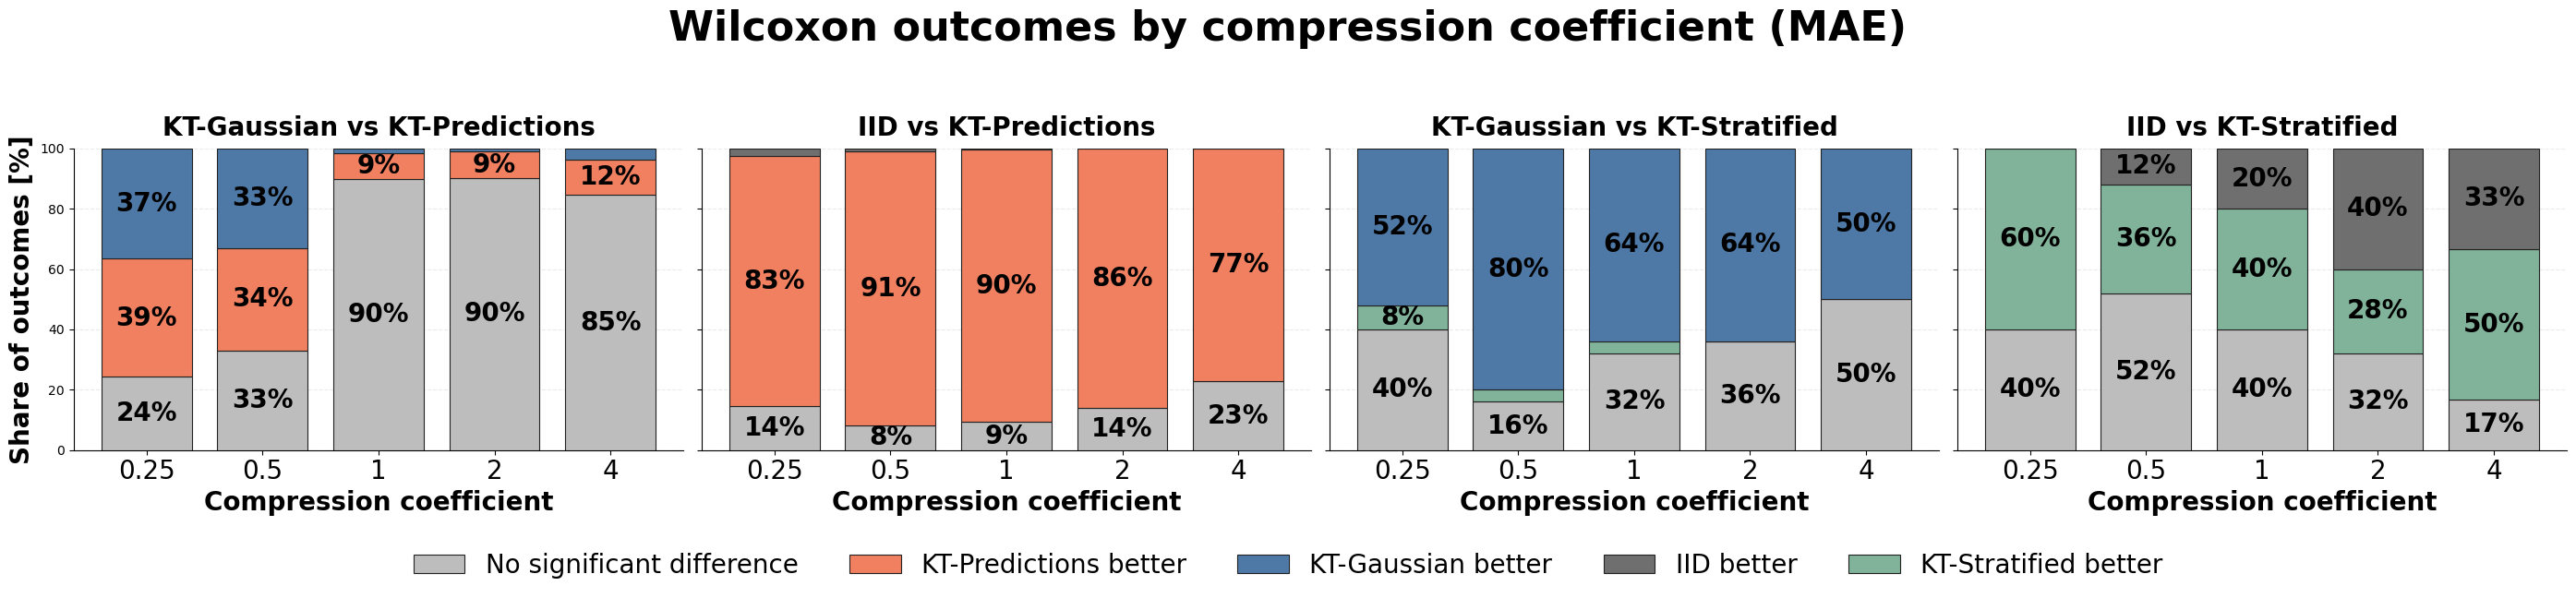

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_wilcoxon_stacked(
    table: pd.DataFrame,
    method_1: str,
    method_2: str,
    ax,
    title: str,
    colors: dict,
    labels_pretty: dict,
):
    df = table.copy()
    df["compression_coefficient"] = pd.to_numeric(df["compression_coefficient"], errors="coerce")
    df = df.dropna(subset=["compression_coefficient", "winner"])

    if df.empty:
        ax.set_axis_off()
        return

    cc_order = sorted(df["compression_coefficient"].unique())
    cc_labels = [f"{cc:g}" for cc in cc_order]

    winner_order = ["No significant difference", method_2, method_1]

    dist = (
        df.groupby(["compression_coefficient", "winner"])
          .size()
          .unstack(fill_value=0)
          .reindex(index=cc_order, columns=winner_order, fill_value=0)
    )

    pct = dist.div(dist.sum(axis=1), axis=0) * 100.0

    x = np.arange(len(cc_order))
    bottom = np.zeros(len(cc_order))

    for cat in winner_order:
        vals = pct[cat].values

        ax.bar(
            x,
            vals,
            bottom=bottom,
            width=0.78,
            color=colors[cat],
            edgecolor="#222222",
            linewidth=0.8,
            label=labels_pretty[cat],
            zorder=3,
        )

        for i, v in enumerate(vals):
            if v >= 6:
                ax.text(
                    x[i],
                    bottom[i] + v / 2,
                    f"{v:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=20,
                    fontweight="bold",
                    color="black",
                    zorder=4,
                )

        bottom += vals

    ax.set_ylim(0, 100)
    ax.set_xticks(x)
    ax.set_xticklabels(cc_labels, fontsize=20)
    ax.set_xlabel("Compression coefficient", fontsize=20, fontweight="bold")
    ax.set_title(title, fontsize=20, fontweight="bold", pad=10)

    ax.grid(axis="y", linestyle="--", alpha=0.25, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# -----------------------------
# RUN (4 PANELS)
# -----------------------------
results = pd.read_csv("../package_metadata/results_all.csv")

comparisons = [
    ("kt_gaussian", "kt_predictions",
     {"No significant difference": "#BDBDBD", "kt_predictions": "#f08060", "kt_gaussian": "#4E79A7"},
     {"No significant difference": "No significant difference", "kt_predictions": "KT-Predictions better", "kt_gaussian": "KT-Gaussian better"},
     "KT-Gaussian vs KT-Predictions"),

    ("iid", "kt_predictions",
     {"No significant difference": "#BDBDBD", "kt_predictions": "#f08060", "iid": "#6F6F6F"},
     {"No significant difference": "No significant difference", "kt_predictions": "KT-Predictions better", "iid": "IID better"},
     "IID vs KT-Predictions"),

    ("kt_gaussian", "kt_stratified",
     {"No significant difference": "#BDBDBD", "kt_stratified": "#81b29a", "kt_gaussian": "#4E79A7"},
     {"No significant difference": "No significant difference", "kt_stratified": "KT-Stratified better", "kt_gaussian": "KT-Gaussian better"},
     "KT-Gaussian vs KT-Stratified"),

     ("iid", "kt_stratified",
     {"No significant difference": "#BDBDBD", "kt_stratified": "#81b29a", "iid": "#6F6F6F"},
     {"No significant difference": "No significant difference", "kt_stratified": "KT-Stratified better", "iid": "IID better"},
     "IID vs KT-Stratified"),
]

tables = []
for m1, m2, _, _, _ in comparisons:
    t = block_wilcoxon_table(results, METRIC, m1, m2, alpha=ALPHA)
    tables.append(t)

fig, axes = plt.subplots(1, 4, figsize=(28, 6), sharey=True)
axes = np.atleast_1d(axes)

for ax, table, (m1, m2, colors, labels_pretty, title) in zip(axes, tables, comparisons):
    plot_wilcoxon_stacked(
        table=table,
        method_1=m1,
        method_2=m2,
        ax=ax,
        title=title,
        colors=colors,
        labels_pretty=labels_pretty,
    )

axes[0].set_ylabel("Share of outcomes [%]", fontsize=20, fontweight="bold")

# Global legend (deduplicated across all panels)
handles_all, labels_all = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles_all.extend(h)
    labels_all.extend(l)

seen = {}
for h, l in zip(handles_all, labels_all):
    if l not in seen:
        seen[l] = h

fig.legend(
    seen.values(),
    seen.keys(),
    loc="lower center",
    ncol=len(seen),
    frameon=False,
    fontsize=20,
    bbox_to_anchor=(0.5, -0.05),
)

fig.suptitle(
    f"Wilcoxon outcomes by compression coefficient ({METRIC.upper()})",
    fontsize=32,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
os.makedirs("./image22", exist_ok=True)
plt.savefig("./image22/wilcoxon_four_cases.pdf", dpi=300, bbox_inches="tight")
plt.show()


/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_13564/208174618.py:90: DtypeWarning: Columns (30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  results = pd.read_csv("../package_metadata/results_all.csv")
/opt/anaconda3/envs/cte/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


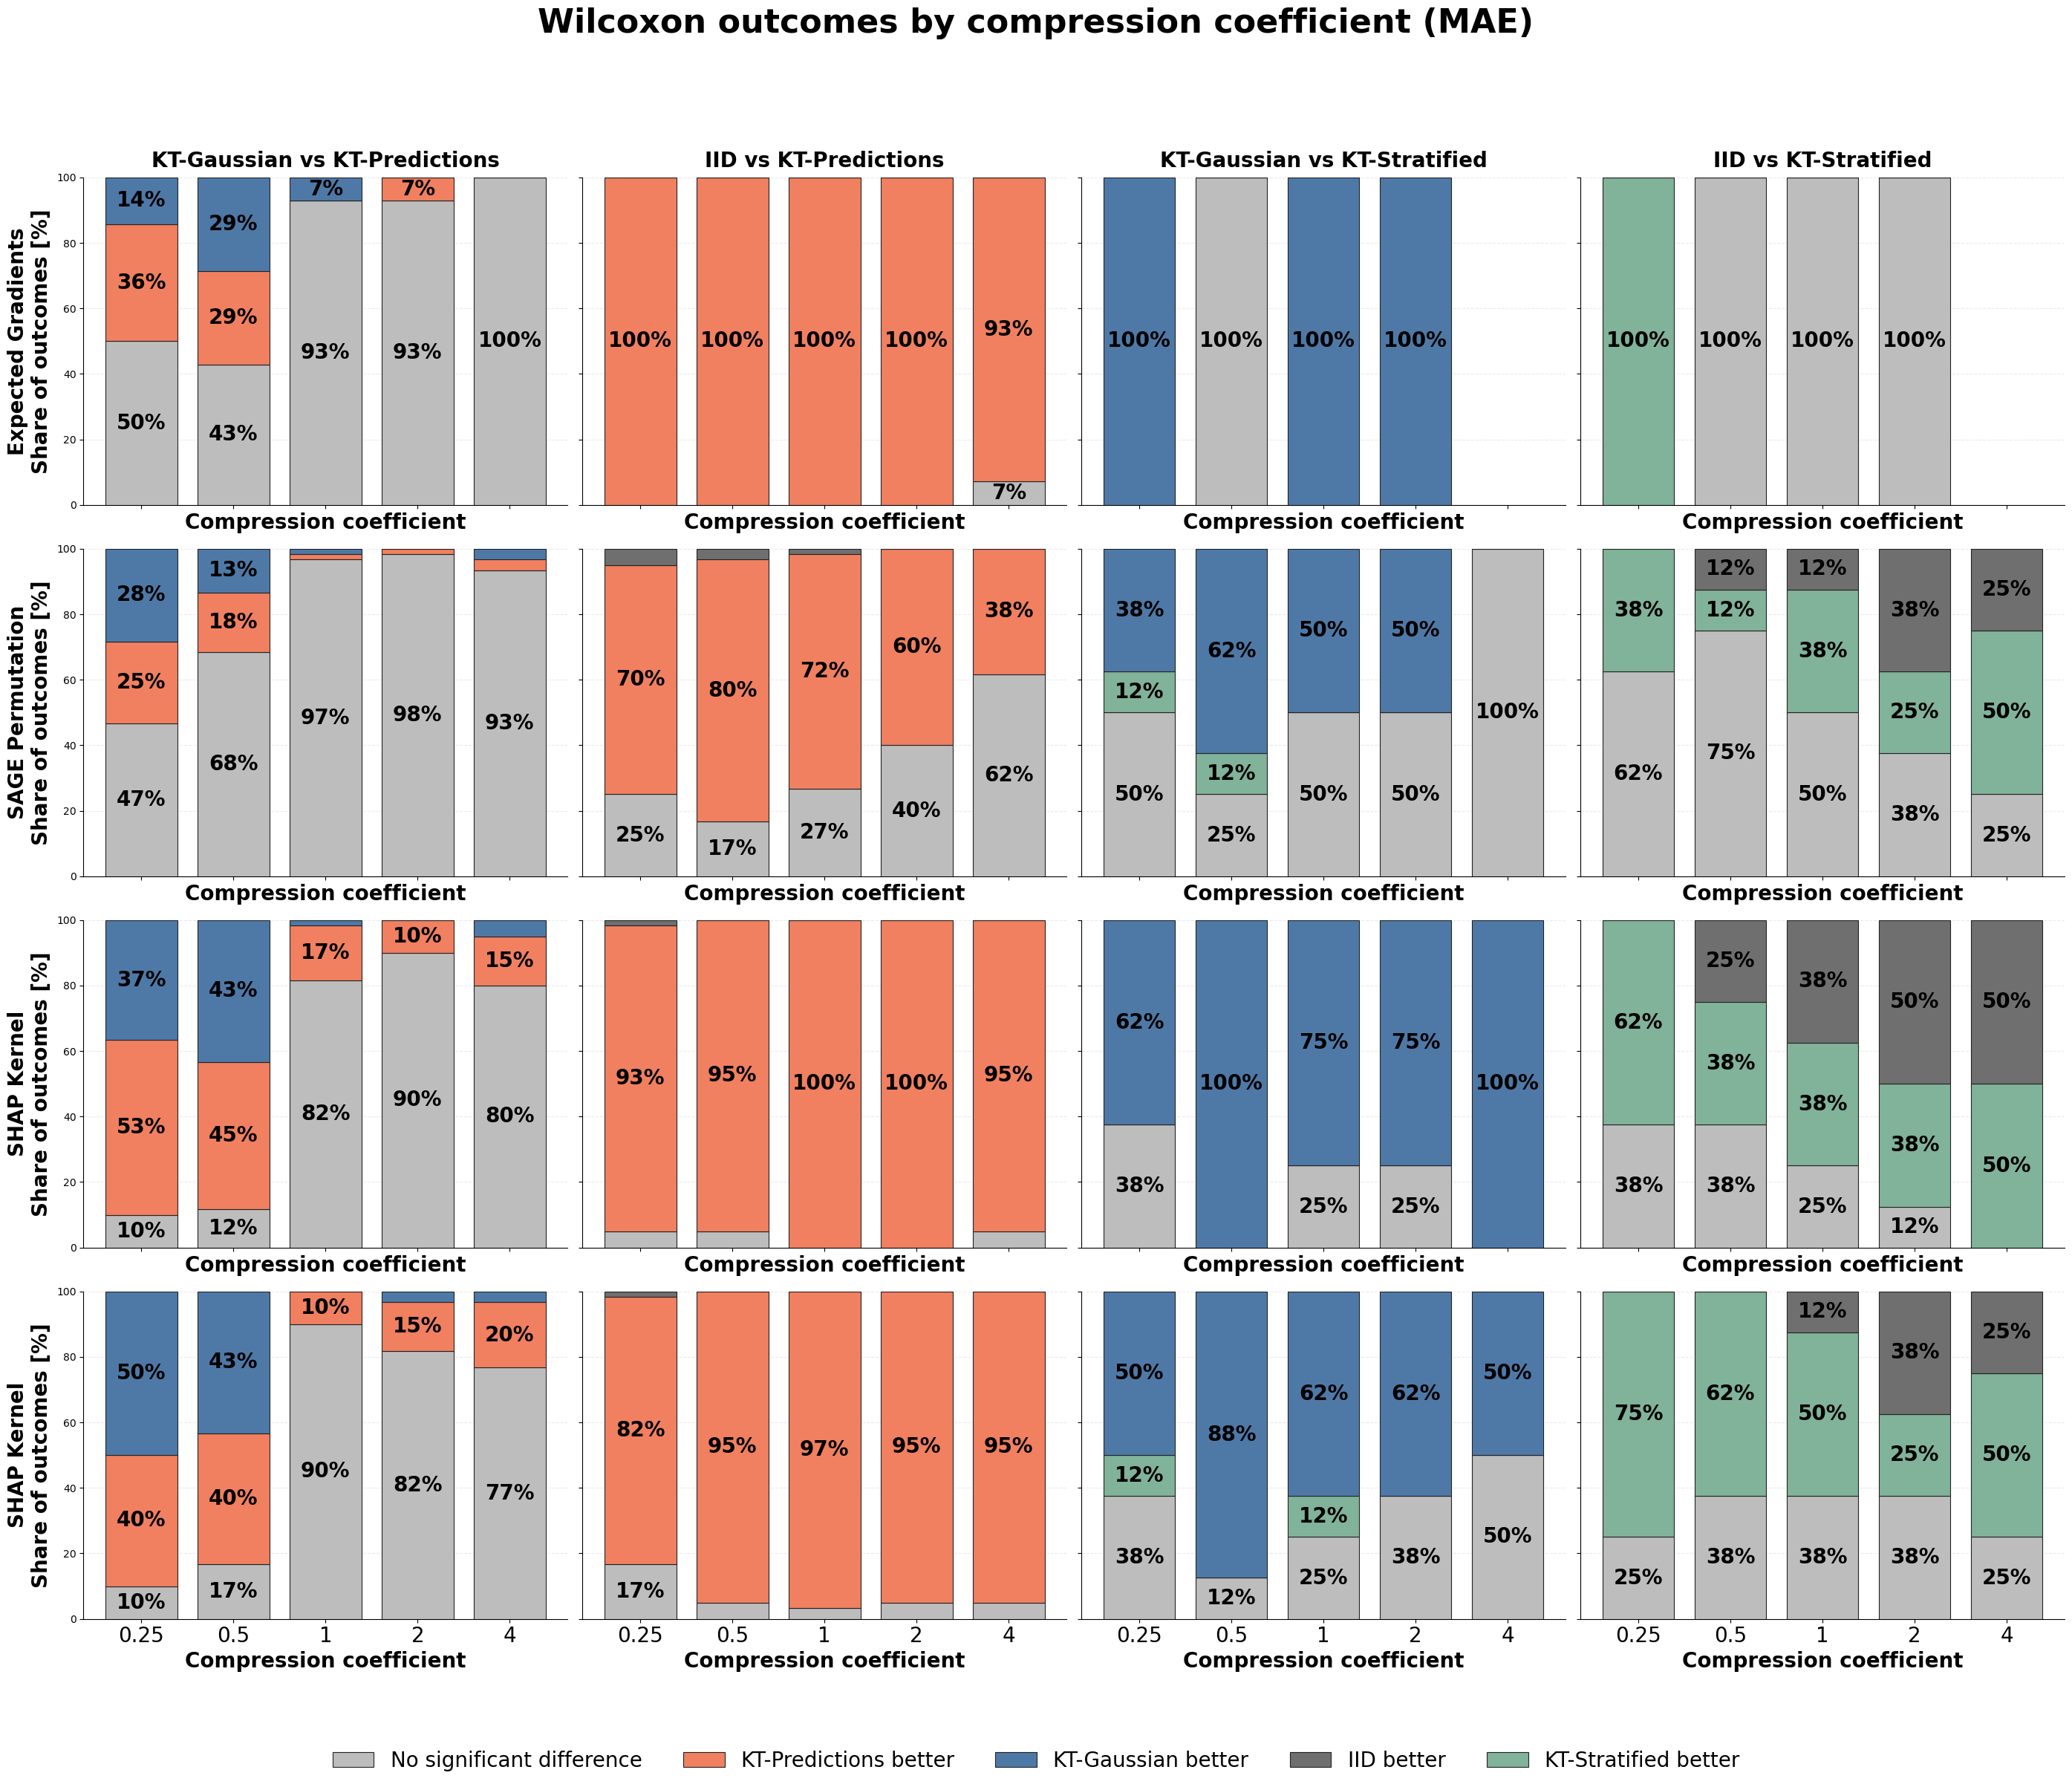

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_wilcoxon_stacked(
    table: pd.DataFrame,
    method_1: str,
    method_2: str,
    ax,
    title: str,
    colors: dict,
    labels_pretty: dict,
):
    df = table.copy()
    df["compression_coefficient"] = pd.to_numeric(df["compression_coefficient"], errors="coerce")
    df = df.dropna(subset=["compression_coefficient", "winner"])

    if df.empty:
        ax.set_axis_off()
        return

    cc_order = sorted(df["compression_coefficient"].unique())
    cc_labels = [f"{cc:g}" for cc in cc_order]

    winner_order = ["No significant difference", method_2, method_1]

    dist = (
        df.groupby(["compression_coefficient", "winner"])
          .size()
          .unstack(fill_value=0)
          .reindex(index=cc_order, columns=winner_order, fill_value=0)
    )

    pct = dist.div(dist.sum(axis=1), axis=0) * 100.0

    x = np.arange(len(cc_order))
    bottom = np.zeros(len(cc_order))

    for cat in winner_order:
        vals = pct[cat].values

        ax.bar(
            x,
            vals,
            bottom=bottom,
            width=0.78,
            color=colors[cat],
            edgecolor="#222222",
            linewidth=0.8,
            label=labels_pretty[cat],
            zorder=3,
        )

        for i, v in enumerate(vals):
            if v >= 6:
                ax.text(
                    x[i],
                    bottom[i] + v / 2,
                    f"{v:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=20,
                    fontweight="bold",
                    color="black",
                    zorder=4,
                )

        bottom += vals

    ax.set_ylim(0, 100)
    ax.set_xticks(x)
    ax.set_xticklabels(cc_labels, fontsize=20)
    
    # Label x-axis only for the bottom row is handled by sharex=True, 
    # but we set the label text generally here (matplotlib hides it automatically if shared)
    ax.set_xlabel("Compression coefficient", fontsize=20, fontweight="bold")
    
    if title:
        ax.set_title(title, fontsize=20, fontweight="bold", pad=10)

    ax.grid(axis="y", linestyle="--", alpha=0.25, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# -----------------------------
# RUN (GRID)
# -----------------------------
results = pd.read_csv("../package_metadata/results_all.csv")

comparisons = [
    ("kt_gaussian", "kt_predictions",
     {"No significant difference": "#BDBDBD", "kt_predictions": "#f08060", "kt_gaussian": "#4E79A7"},
     {"No significant difference": "No significant difference", "kt_predictions": "KT-Predictions better", "kt_gaussian": "KT-Gaussian better"},
     "KT-Gaussian vs KT-Predictions"),

    ("iid", "kt_predictions",
     {"No significant difference": "#BDBDBD", "kt_predictions": "#f08060", "iid": "#6F6F6F"},
     {"No significant difference": "No significant difference", "kt_predictions": "KT-Predictions better", "iid": "IID better"},
     "IID vs KT-Predictions"),

    ("kt_gaussian", "kt_stratified",
     {"No significant difference": "#BDBDBD", "kt_stratified": "#81b29a", "kt_gaussian": "#4E79A7"},
     {"No significant difference": "No significant difference", "kt_stratified": "KT-Stratified better", "kt_gaussian": "KT-Gaussian better"},
     "KT-Gaussian vs KT-Stratified"),

     ("iid", "kt_stratified",
     {"No significant difference": "#BDBDBD", "kt_stratified": "#81b29a", "iid": "#6F6F6F"},
     {"No significant difference": "No significant difference", "kt_stratified": "KT-Stratified better", "iid": "IID better"},
     "IID vs KT-Stratified"),
]

methods = sorted(results["explainer_total"].unique())
n_rows = len(methods)
n_cols = len(comparisons)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(28, 6 * n_rows), sharey=True, sharex=True)

if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for i, method in enumerate(methods):
    results_sub = results[results["explainer_total"] == method]
    
    for j, (m1, m2, colors, labels_pretty, title) in enumerate(comparisons):
        table = block_wilcoxon_table(results_sub, METRIC, m1, m2, alpha=ALPHA)
        
        ax = axes[i, j]
        
        plot_title = title if i == 0 else ""
        
        plot_wilcoxon_stacked(
            table=table,
            method_1=m1,
            method_2=m2,
            ax=ax,
            title=plot_title,
            colors=colors,
            labels_pretty=labels_pretty,
        )

        if j == 0:
            if method == "expected_gradients":
                display_name = "Expected Gradients"
            elif method == "sage_permutation":
                display_name = "SAGE Permutation"
            elif method == "shap_kernel":
                display_name = "SHAP Kernel"
            elif display_name == "shapiq_kernel":
                display_name = "SHAP-IQ Kernel"
            ax.set_ylabel(f"{display_name}\nShare of outcomes [%]", fontsize=20, fontweight="bold")

handles_all, labels_all = [], []
for ax_row in axes:
    for ax in ax_row:
        h, l = ax.get_legend_handles_labels()
        handles_all.extend(h)
        labels_all.extend(l)

seen = {}
for h, l in zip(handles_all, labels_all):
    if l not in seen:
        seen[l] = h

fig.legend(
    seen.values(),
    seen.keys(),
    loc="lower center",
    ncol=len(seen),
    frameon=False,
    fontsize=20,
    bbox_to_anchor=(0.5, 0.0),
)

fig.suptitle(
    f"Wilcoxon outcomes by compression coefficient ({METRIC.upper()})",
    fontsize=32,
    fontweight="bold",
    y=1.0, 
)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
os.makedirs("./image22", exist_ok=True)
plt.savefig("./image22/wilcoxon_grid_by_explanation_method.pdf", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_47015/49045999.py:94: DtypeWarning: Columns (30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  results = pd.read_csv("../package_metadata/results_all.csv")
/opt/anaconda3/envs/compress_explain/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


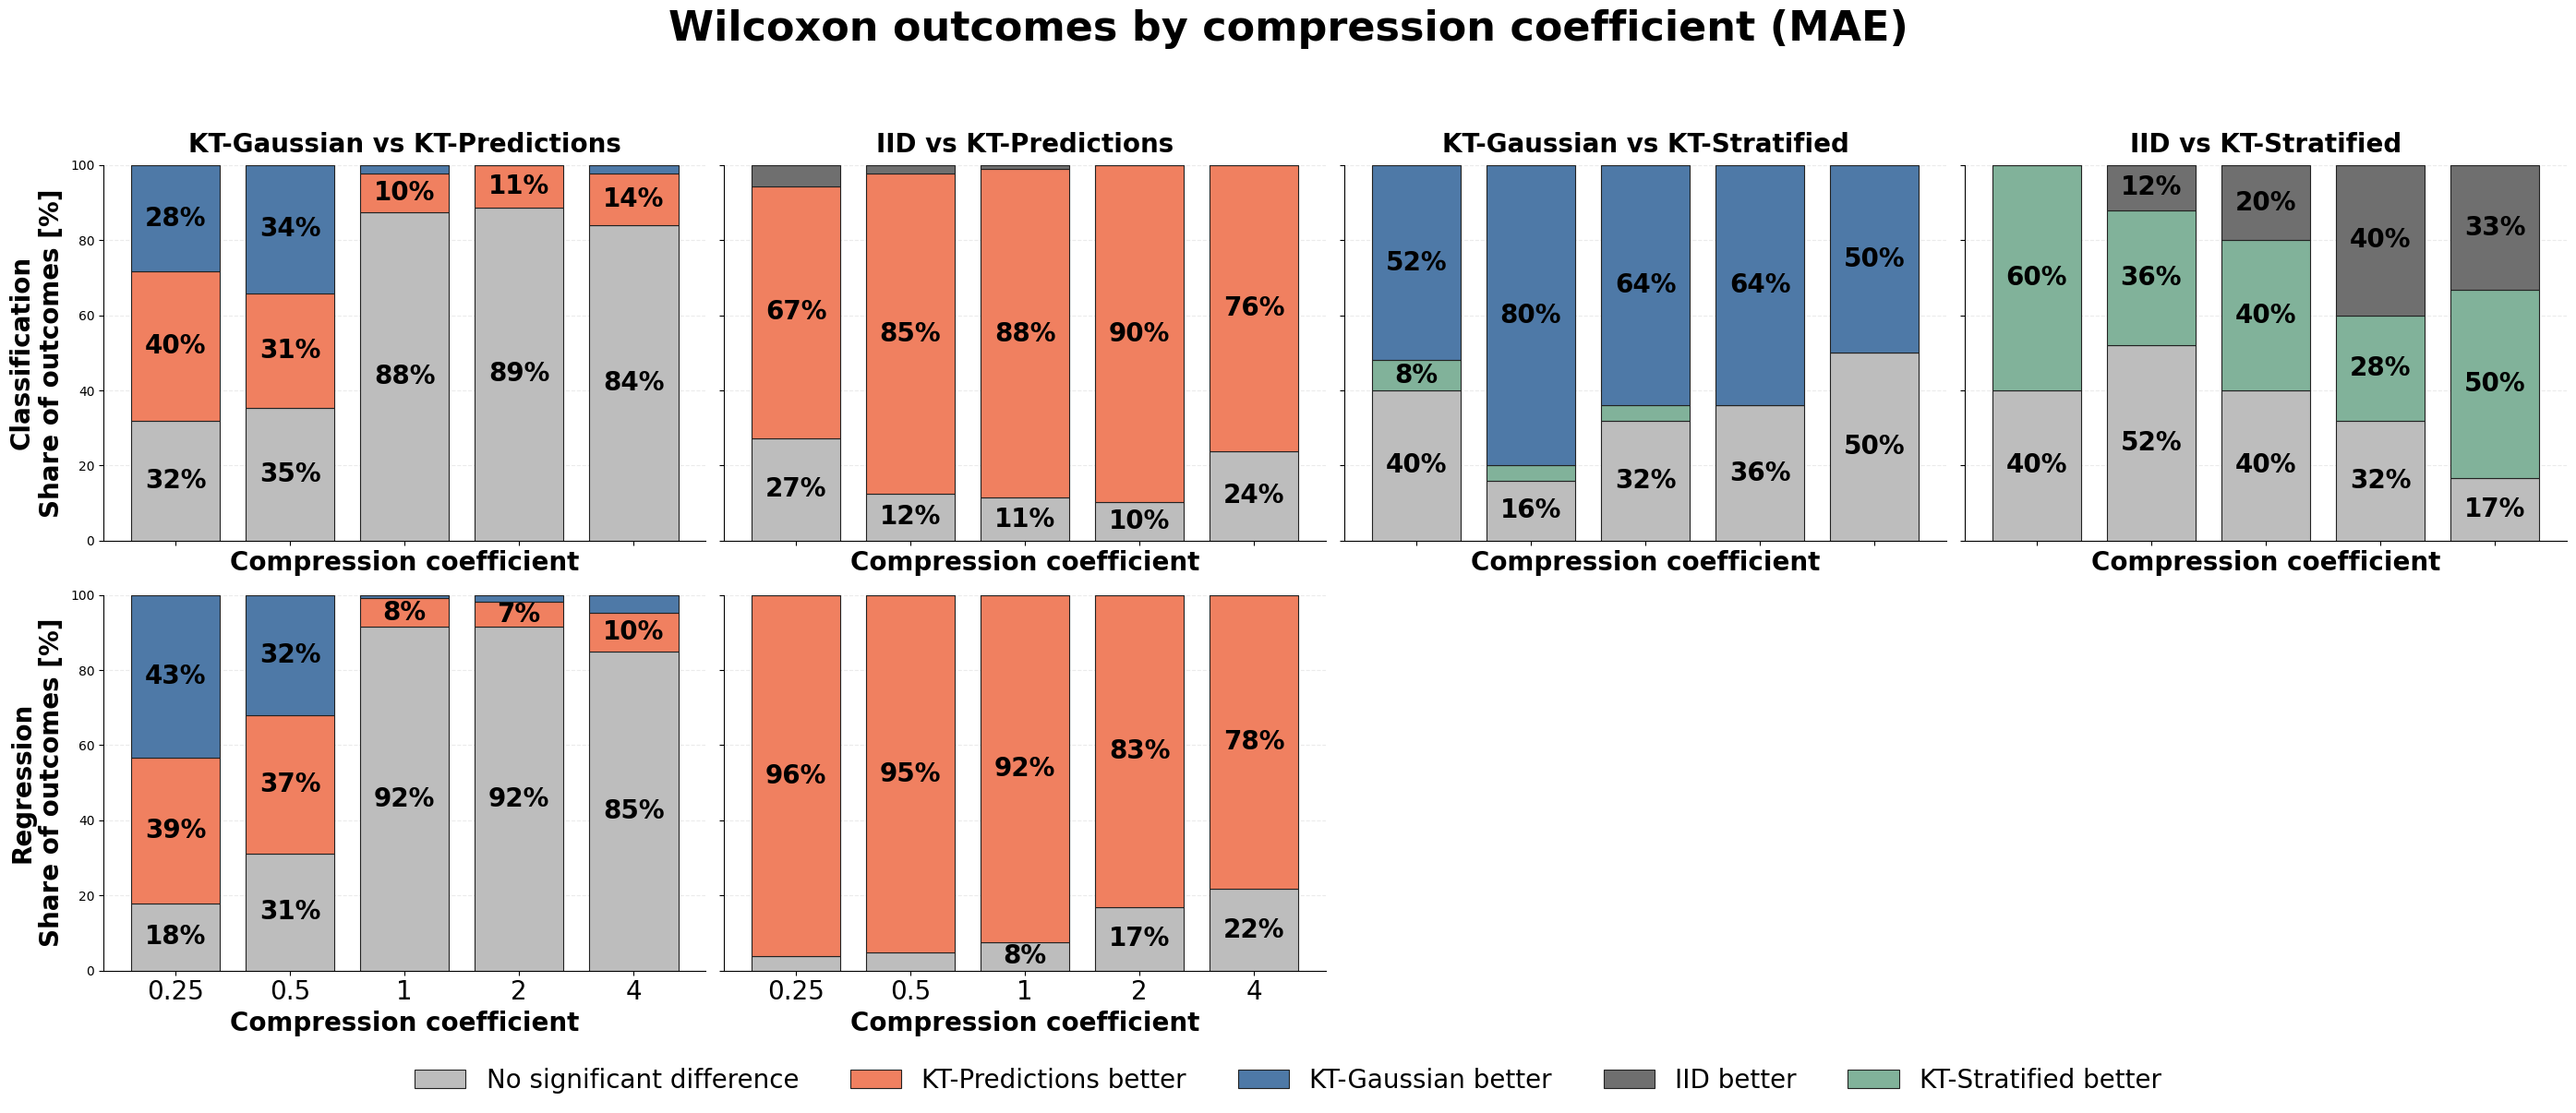

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_wilcoxon_stacked(
    table: pd.DataFrame,
    method_1: str,
    method_2: str,
    ax,
    title: str,
    colors: dict,
    labels_pretty: dict,
):
    df = table.copy()
    df["compression_coefficient"] = pd.to_numeric(df["compression_coefficient"], errors="coerce")
    df = df.dropna(subset=["compression_coefficient", "winner"])

    if df.empty:
        ax.set_axis_off()
        return

    cc_order = sorted(df["compression_coefficient"].unique())
    cc_labels = [f"{cc:g}" for cc in cc_order]

    winner_order = ["No significant difference", method_2, method_1]

    dist = (
        df.groupby(["compression_coefficient", "winner"])
          .size()
          .unstack(fill_value=0)
          .reindex(index=cc_order, columns=winner_order, fill_value=0)
    )

    pct = dist.div(dist.sum(axis=1), axis=0) * 100.0

    x = np.arange(len(cc_order))
    bottom = np.zeros(len(cc_order))

    for cat in winner_order:
        vals = pct[cat].values

        ax.bar(
            x,
            vals,
            bottom=bottom,
            width=0.78,
            color=colors[cat],
            edgecolor="#222222",
            linewidth=0.8,
            label=labels_pretty[cat],
            zorder=3,
        )

        for i, v in enumerate(vals):
            if v >= 6:
                ax.text(
                    x[i],
                    bottom[i] + v / 2,
                    f"{v:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=20,
                    fontweight="bold",
                    color="black",
                    zorder=4,
                )

        bottom += vals

    ax.set_ylim(0, 100)
    ax.set_xticks(x)
    ax.set_xticklabels(cc_labels, fontsize=20)
    
    ax.set_xlabel("Compression coefficient", fontsize=20, fontweight="bold")
    
    if title:
        ax.set_title(title, fontsize=20, fontweight="bold", pad=10)

    ax.grid(axis="y", linestyle="--", alpha=0.25, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

results = pd.read_csv("../package_metadata/results_all.csv")

comparisons = [
    ("kt_gaussian", "kt_predictions",
     {"No significant difference": "#BDBDBD", "kt_predictions": "#f08060", "kt_gaussian": "#4E79A7"},
     {"No significant difference": "No significant difference", "kt_predictions": "KT Predictions better", "kt_gaussian": "KT Gaussian better"},
     "KT Gaussian vs KT Predictions"),

    ("iid", "kt_predictions",
     {"No significant difference": "#BDBDBD", "kt_predictions": "#f08060", "iid": "#6F6F6F"},
     {"No significant difference": "No significant difference", "kt_predictions": "KT Predictions better", "iid": "IID better"},
     "IID vs KT Predictions"),

    ("kt_gaussian", "kt_stratified",
     {"No significant difference": "#BDBDBD", "kt_stratified": "#81b29a", "kt_gaussian": "#4E79A7"},
     {"No significant difference": "No significant difference", "kt_stratified": "KT Stratified better", "kt_gaussian": "KT Gaussian better"},
     "KT Gaussian vs KT Stratified"),

     ("iid", "kt_stratified",
     {"No significant difference": "#BDBDBD", "kt_stratified": "#81b29a", "iid": "#6F6F6F"},
     {"No significant difference": "No significant difference", "kt_stratified": "KT Stratified better", "iid": "IID better"},
     "IID vs KT Stratified"),
]

tasks = sorted(results["task"].unique()) 

n_rows = len(tasks)
n_cols = len(comparisons)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(28, 6 * n_rows), sharey=True, sharex=True)

if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for i, task in enumerate(tasks):
    # Filter data for the current task
    results_sub = results[results["task"] == task]
    
    for j, (m1, m2, colors, labels_pretty, title) in enumerate(comparisons):
        ax = axes[i, j]

        if task == "regression" and ("kt_stratified" in [m1, m2]):
            ax.set_axis_off()
            continue
            
        table = block_wilcoxon_table(results_sub, METRIC, m1, m2, alpha=ALPHA)
        
        plot_title = title if i == 0 else ""
        
        plot_wilcoxon_stacked(
            table=table,
            method_1=m1,
            method_2=m2,
            ax=ax,
            title=plot_title,
            colors=colors,
            labels_pretty=labels_pretty,
        )

        if j == 0:
            display_name = task.capitalize() 
            ax.set_ylabel(f"{display_name}\nShare of outcomes [%]", fontsize=20, fontweight="bold")

# -----------------------------
# LEGEND & SAVING
# -----------------------------
handles_all, labels_all = [], []
for ax_row in axes:
    for ax in ax_row:
        # Check if axis is visible (it might be turned off for regression/stratified)
        if ax.axison: 
            h, l = ax.get_legend_handles_labels()
            handles_all.extend(h)
            labels_all.extend(l)

seen = {}
for h, l in zip(handles_all, labels_all):
    if l not in seen:
        seen[l] = h

fig.legend(
    seen.values(),
    seen.keys(),
    loc="lower center",
    ncol=len(seen),
    frameon=False,
    fontsize=20,
    bbox_to_anchor=(0.5, 0.0),
)

fig.suptitle(
    f"Wilcoxon outcomes by compression coefficient ({METRIC.upper()})",
    fontsize=32,
    fontweight="bold",
    y=1.0, 
)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
os.makedirs("./image22", exist_ok=True)
plt.savefig("./image22/wilcoxon_grid_by_task.pdf", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_13564/1006159946.py:87: DtypeWarning: Columns (30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  results = pd.read_csv("../package_metadata/results_all.csv")


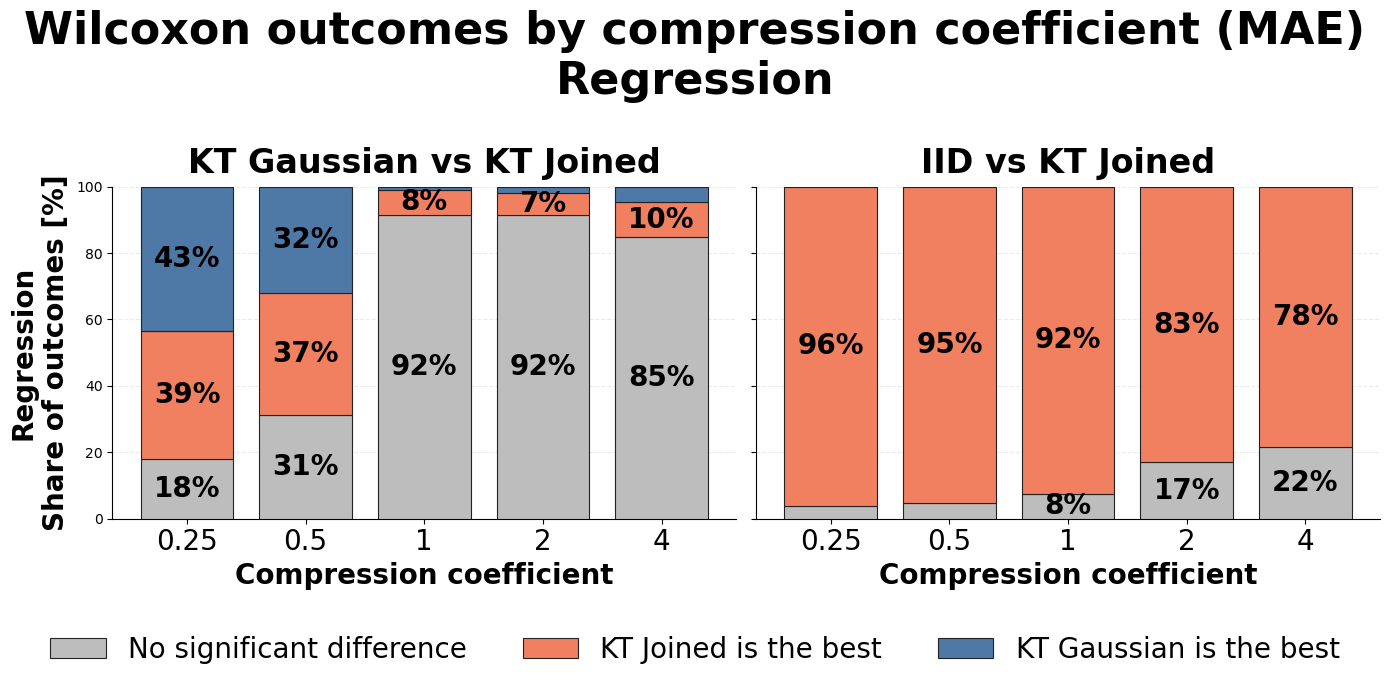

In [49]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_wilcoxon_stacked(
    table: pd.DataFrame,
    method_1: str,
    method_2: str,
    ax,
    title: str,
    colors: dict,
    labels_pretty: dict,
):
    df = table.copy()
    df["compression_coefficient"] = pd.to_numeric(df["compression_coefficient"], errors="coerce")
    df = df.dropna(subset=["compression_coefficient", "winner"])

    if df.empty:
        ax.set_axis_off()
        return

    cc_order = sorted(df["compression_coefficient"].unique())
    cc_labels = [f"{cc:g}" for cc in cc_order]

    winner_order = ["No significant difference", method_2, method_1]

    dist = (
        df.groupby(["compression_coefficient", "winner"])
          .size()
          .unstack(fill_value=0)
          .reindex(index=cc_order, columns=winner_order, fill_value=0)
    )

    pct = dist.div(dist.sum(axis=1), axis=0) * 100.0

    x = np.arange(len(cc_order))
    bottom = np.zeros(len(cc_order))

    for cat in winner_order:
        vals = pct[cat].values

        ax.bar(
            x,
            vals,
            bottom=bottom,
            width=0.78,
            color=colors[cat],
            edgecolor="#222222",
            linewidth=0.8,
            label=labels_pretty[cat],
            zorder=3,
        )

        for i, v in enumerate(vals):
            if v >= 6:
                ax.text(
                    x[i],
                    bottom[i] + v / 2,
                    f"{v:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=20,
                    fontweight="bold",
                    color="black",
                    zorder=4,
                )

        bottom += vals

    ax.set_ylim(0, 100)
    ax.set_xticks(x)
    ax.set_xticklabels(cc_labels, fontsize=20)
    ax.set_xlabel("Compression coefficient", fontsize=20, fontweight="bold")

    if title:
        ax.set_title(title, fontsize=24, fontweight="bold", pad=10)

    ax.grid(axis="y", linestyle="--", alpha=0.25, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# -----------------------------
# DATA
# -----------------------------
results = pd.read_csv("../package_metadata/results_all.csv")

comparisons = [
    ("kt_gaussian", "kt_predictions",
     {"No significant difference": "#BDBDBD", "kt_predictions": "#f08060", "kt_gaussian": "#4E79A7"},
     {"No significant difference": "No significant difference", "kt_predictions": "KT Joined is the best", "kt_gaussian": "KT Gaussian is the best"},
     "KT Gaussian vs KT Joined"),

    ("iid", "kt_predictions",
     {"No significant difference": "#BDBDBD", "kt_predictions": "#f08060", "iid": "#6F6F6F"},
     {"No significant difference": "No significant difference", "kt_predictions": "KT Joined is the best", "iid": "IID is the best"},
     "IID vs KT Joined"),

    # ("kt_gaussian", "kt_stratified",
    #  {"No significant difference": "#BDBDBD", "kt_stratified": "#81b29a", "kt_gaussian": "#4E79A7"},
    #  {"No significant difference": "No significant difference", "kt_stratified": "KT Stratified better", "kt_gaussian": "KT Gaussian better"},
    #  "KT Gaussian vs KT Stratified"),

    # ("iid", "kt_stratified",
    #  {"No significant difference": "#BDBDBD", "kt_stratified": "#81b29a", "iid": "#6F6F6F"},
    #  {"No significant difference": "No significant difference", "kt_stratified": "KT Stratified better", "iid": "IID better"},
    #  "IID vs KT Stratified"),
]

# -----------------------------
# ONLY REGRESSION
# -----------------------------
task = "regression"
results_sub = results[results["task"] == task].copy()

n_rows = 1
n_cols = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 7), sharey=True, sharex=True)

# make iterable
if n_cols == 1:
    axes = [axes]

for j, (m1, m2, colors, labels_pretty, title) in enumerate(comparisons):
    ax = axes[j]

    # no stratified comparisons for regression -> hide those panels
    if "kt_stratified" in [m1, m2]:
        ax.set_axis_off()
        continue

    table = block_wilcoxon_table(results_sub, METRIC, m1, m2, alpha=ALPHA)

    plot_wilcoxon_stacked(
        table=table,
        method_1=m1,
        method_2=m2,
        ax=ax,
        title=title,  # show titles (single row)
        colors=colors,
        labels_pretty=labels_pretty,
    )

    if j == 0:
        ax.set_ylabel("Regression\nShare of outcomes [%]", fontsize=20, fontweight="bold")

# # -----------------------------
# # LEGEND & SAVING
# # -----------------------------
# handles_all, labels_all = [], []
# for ax in axes:
#     if ax.axison:
#         h, l = ax.get_legend_handles_labels()
#         handles_all.extend(h)
#         labels_all.extend(l)

# # dedupe + DROP IID legend entry
# seen = {}
# for h, l in zip(handles_all, labels_all):
#     if l not in seen and "IID" not in l:   # <- removes IID label
#         seen[l] = h

# fig.legend(
#     seen.values(),
#     seen.keys(),
#     loc="lower center",
#     ncol=len(seen),
#     frameon=False,
#     fontsize=20,
#     bbox_to_anchor=(0.5, -0.02),  # <- lower than before
# )

# fig.suptitle(
#     f"Wilcoxon outcomes by compression coefficient ({METRIC.upper()})\nRegression",
#     fontsize=32,
#     fontweight="bold",
#     y=1.02,
# )

# plt.tight_layout(rect=[0, 0.10, 1, 0.93])  # <- more bottom space for lower legend
# os.makedirs("./image22", exist_ok=True)
# plt.savefig("./image22/wilcoxon_regression_only.pdf", dpi=300, bbox_inches="tight")
# plt.show()

# -----------------------------
# LEGEND & SAVING
# -----------------------------
handles_all, labels_all = [], []
for ax in axes:
    if ax.axison:
        h, l = ax.get_legend_handles_labels()
        handles_all.extend(h)
        labels_all.extend(l)

# dedupe + DROP IID legend entry
seen = {}
for h, l in zip(handles_all, labels_all):
    if l not in seen and "IID" not in l:   # <- removes IID label
        seen[l] = h

fig.legend(
    seen.values(),
    seen.keys(),
    loc="lower center",
    ncol=len(seen),
    frameon=False,
    fontsize=20,
    bbox_to_anchor=(0.5, -0.02),  # <- lower than before
)

fig.suptitle(
    f"Wilcoxon outcomes by compression coefficient ({METRIC.upper()})\nRegression",
    fontsize=32,
    fontweight="bold",
    y=0.95,
)

plt.tight_layout(rect=[0, 0.10, 1, 0.93])  # <- more bottom space for lower legend
os.makedirs("./image22", exist_ok=True)
plt.savefig("./image22/wilcoxon_regression_only.pdf", dpi=300, bbox_inches="tight")
plt.show()


/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_13564/3105966730.py:8: DtypeWarning: Columns (30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  results = pd.read_csv("../package_metadata/results_all.csv")
/opt/anaconda3/envs/cte/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


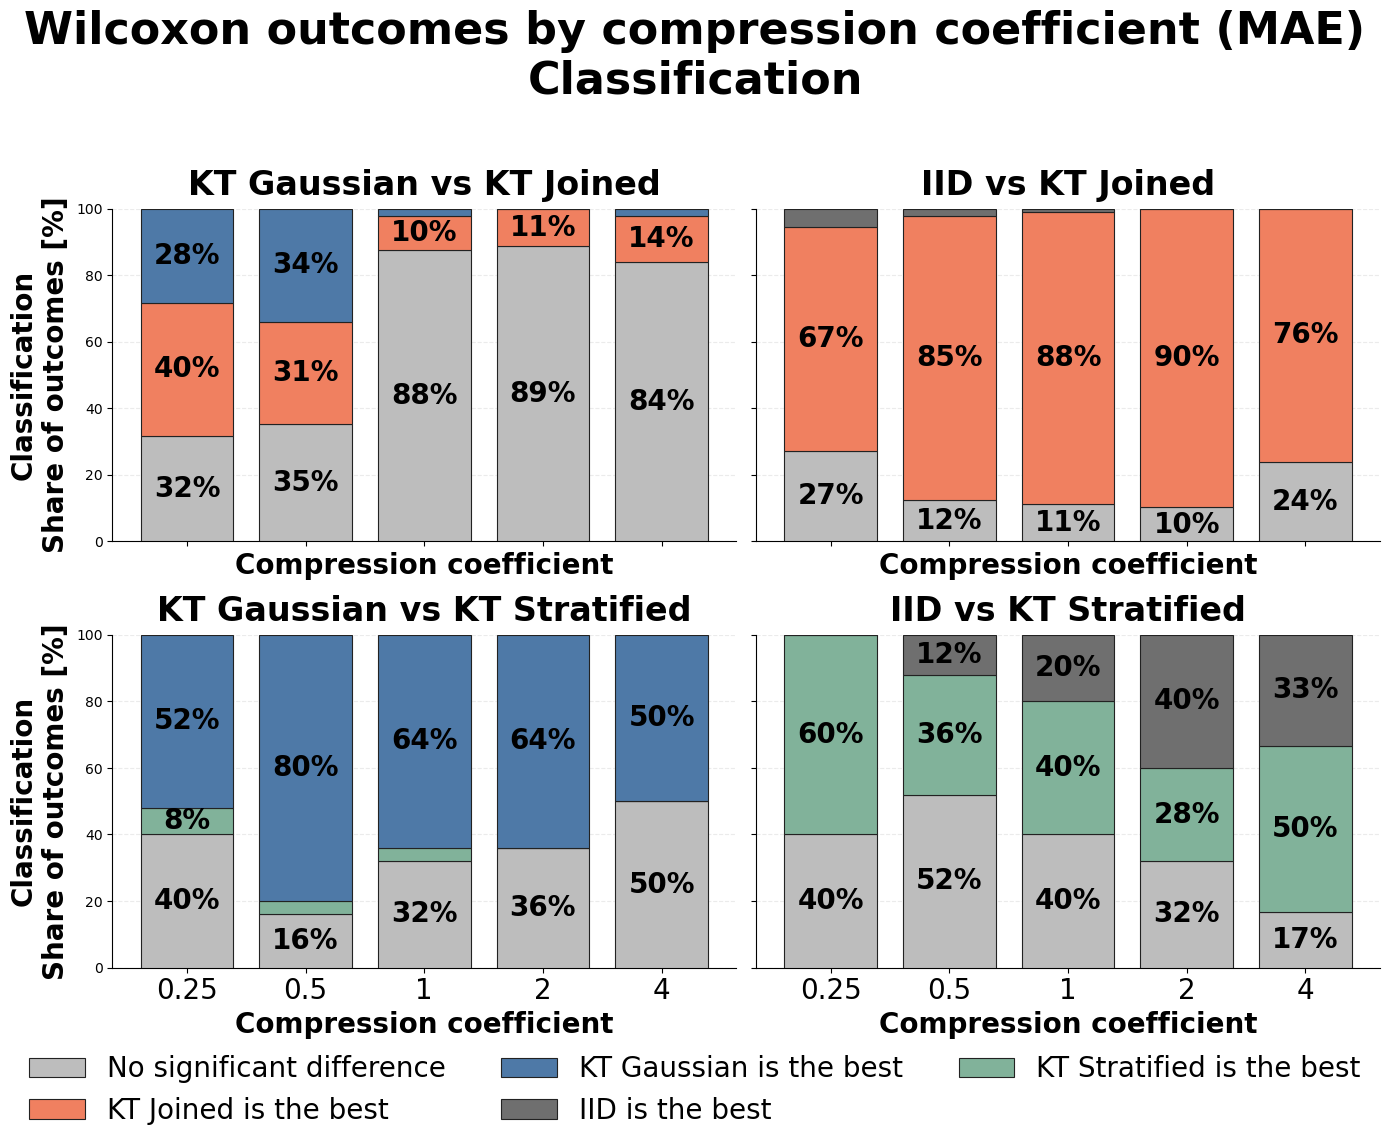

In [42]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- your plot_wilcoxon_stacked stays unchanged above ---

results = pd.read_csv("../package_metadata/results_all.csv")

comparisons = [
    ("kt_gaussian", "kt_predictions",
     {"No significant difference": "#BDBDBD", "kt_predictions": "#f08060", "kt_gaussian": "#4E79A7"},
     {"No significant difference": "No significant difference",
      "kt_predictions": "KT Joined is the best",
      "kt_gaussian": "KT Gaussian is the best"},
     "KT Gaussian vs KT Joined"),

    ("iid", "kt_predictions",
     {"No significant difference": "#BDBDBD", "kt_predictions": "#f08060", "iid": "#6F6F6F"},
     {"No significant difference": "No significant difference",
      "kt_predictions": "KT Joined is the best",
      "iid": "IID is the best"},
     "IID vs KT Joined"),

    ("kt_gaussian", "kt_stratified",
     {"No significant difference": "#BDBDBD", "kt_stratified": "#81b29a", "kt_gaussian": "#4E79A7"},
     {"No significant difference": "No significant difference",
      "kt_stratified": "KT Stratified is the best",
      "kt_gaussian": "KT Gaussian is the best"},
     "KT Gaussian vs KT Stratified"),

    ("iid", "kt_stratified",
     {"No significant difference": "#BDBDBD", "kt_stratified": "#81b29a", "iid": "#6F6F6F"},
     {"No significant difference": "No significant difference",
      "kt_stratified": "KT Stratified is the best",
      "iid": "IID is the best"},
     "IID vs KT Stratified"),
]

# -----------------------------
# ONLY CLASSIFICATION (2x2)
# -----------------------------
task = "classification"
results_sub = results[results["task"] == task].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 12), sharey=True, sharex=True)
axes = axes.flatten()  # IMPORTANT for axes[j]

for j, (m1, m2, colors, labels_pretty, title) in enumerate(comparisons):
    ax = axes[j]

    table = block_wilcoxon_table(results_sub, METRIC, m1, m2, alpha=ALPHA)

    plot_wilcoxon_stacked(
        table=table,
        method_1=m1,
        method_2=m2,
        ax=ax,
        title=title,          # show titles (one row only anyway)
        colors=colors,
        labels_pretty=labels_pretty,
    )

# one y-label on the left column (optional, but nice)
axes[0].set_ylabel("Classification\nShare of outcomes [%]", fontsize=20, fontweight="bold")
axes[2].set_ylabel("Classification\nShare of outcomes [%]", fontsize=20, fontweight="bold")

# -----------------------------
# LEGEND (simple, like your working one)
# -----------------------------
handles_all, labels_all = [], []
for ax in axes:
    if ax.axison:
        h, l = ax.get_legend_handles_labels()
        handles_all.extend(h)
        labels_all.extend(l)

seen = {}
for h, l in zip(handles_all, labels_all):
    if l not in seen:
        seen[l] = h
ncol = int(np.ceil(len(seen) / 2))

fig.legend(
    seen.values(),
    seen.keys(),
    loc="lower center",
    ncol=ncol,              # <- 2 lines
    frameon=False,
    fontsize=20,
    bbox_to_anchor=(0.5, 0.0),
)


fig.suptitle(
    f"Wilcoxon outcomes by compression coefficient ({METRIC.upper()})\nClassification",
    fontsize=32,
    fontweight="bold",
    y=0.95,
)

plt.tight_layout(rect=[0, 0.08, 1, 0.92])
os.makedirs("./image22", exist_ok=True)
plt.savefig("./image22/wilcoxon_classification_only.pdf", dpi=300, bbox_inches="tight")
plt.show()


/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_13564/1096673102.py:8: DtypeWarning: Columns (30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  results = pd.read_csv("../package_metadata/results_all.csv")
/opt/anaconda3/envs/cte/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


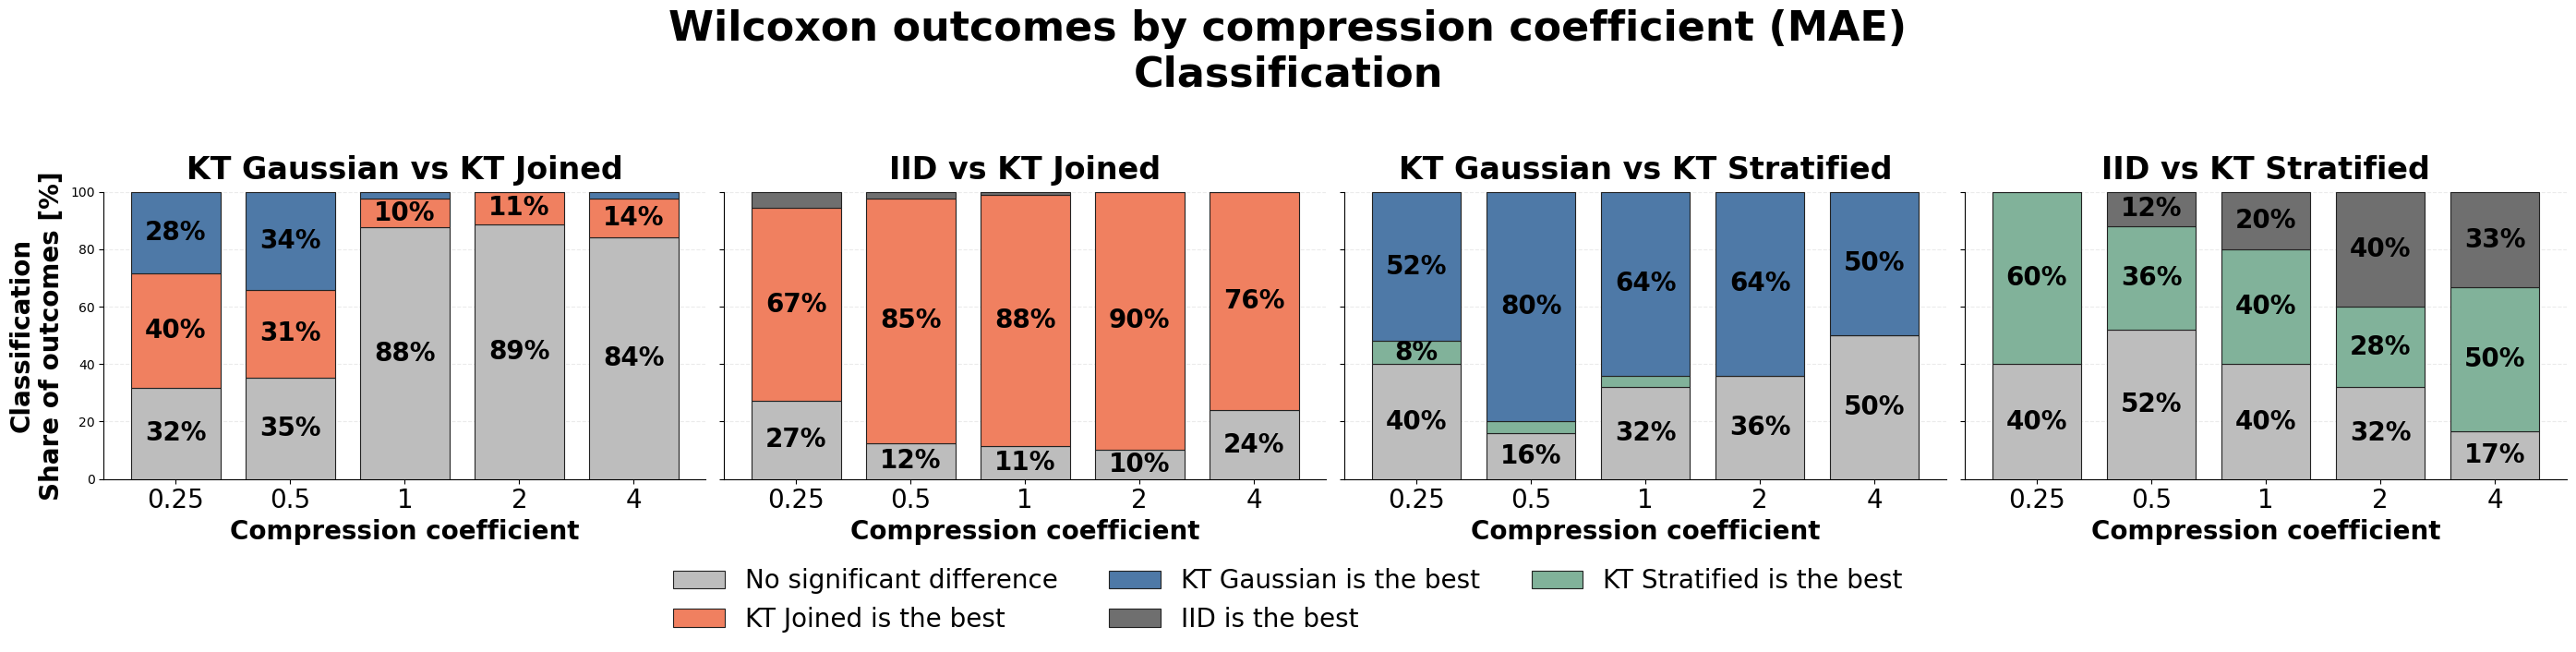

In [48]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- your plot_wilcoxon_stacked stays unchanged above ---

results = pd.read_csv("../package_metadata/results_all.csv")

comparisons = [
    ("kt_gaussian", "kt_predictions",
     {"No significant difference": "#BDBDBD", "kt_predictions": "#f08060", "kt_gaussian": "#4E79A7"},
     {"No significant difference": "No significant difference",
      "kt_predictions": "KT Joined is the best",
      "kt_gaussian": "KT Gaussian is the best"},
     "KT Gaussian vs KT Joined"),

    ("iid", "kt_predictions",
     {"No significant difference": "#BDBDBD", "kt_predictions": "#f08060", "iid": "#6F6F6F"},
     {"No significant difference": "No significant difference",
      "kt_predictions": "KT Joined is the best",
      "iid": "IID is the best"},
     "IID vs KT Joined"),

    ("kt_gaussian", "kt_stratified",
     {"No significant difference": "#BDBDBD", "kt_stratified": "#81b29a", "kt_gaussian": "#4E79A7"},
     {"No significant difference": "No significant difference",
      "kt_stratified": "KT Stratified is the best",
      "kt_gaussian": "KT Gaussian is the best"},
     "KT Gaussian vs KT Stratified"),

    ("iid", "kt_stratified",
     {"No significant difference": "#BDBDBD", "kt_stratified": "#81b29a", "iid": "#6F6F6F"},
     {"No significant difference": "No significant difference",
      "kt_stratified": "KT Stratified is the best",
      "iid": "IID is the best"},
     "IID vs KT Stratified"),
]

# -----------------------------
# ONLY CLASSIFICATION (1x4)
# -----------------------------
task = "classification"
results_sub = results[results["task"] == task].copy()

fig, axes = plt.subplots(1, 4, figsize=(28, 7), sharey=True, sharex=True)
# axes is already iterable (len=4)

for j, (m1, m2, colors, labels_pretty, title) in enumerate(comparisons):
    ax = axes[j]

    table = block_wilcoxon_table(results_sub, METRIC, m1, m2, alpha=ALPHA)

    plot_wilcoxon_stacked(
        table=table,
        method_1=m1,
        method_2=m2,
        ax=ax,
        title=title,
        colors=colors,
        labels_pretty=labels_pretty,
    )

# one y-label (leftmost plot)
axes[0].set_ylabel("Classification\nShare of outcomes [%]", fontsize=20, fontweight="bold")

# -----------------------------
# LEGEND (2 lines)
# -----------------------------
handles_all, labels_all = [], []
for ax in axes:
    if ax.axison:
        h, l = ax.get_legend_handles_labels()
        handles_all.extend(h)
        labels_all.extend(l)

seen = {}
for h, l in zip(handles_all, labels_all):
    if l not in seen:
        seen[l] = h

ncol = int(np.ceil(len(seen) / 2))  # 2 lines

fig.legend(
    seen.values(),
    seen.keys(),
    loc="lower center",
    ncol=ncol,
    frameon=False,
    fontsize=20,
    bbox_to_anchor=(0.5, -0.05),
)

fig.suptitle(
    f"Wilcoxon outcomes by compression coefficient ({METRIC.upper()})\nClassification",
    fontsize=32,
    fontweight="bold",
    y=0.95,
)

plt.tight_layout(rect=[0, 0.10, 1, 0.90])
os.makedirs("./image22", exist_ok=True)
plt.savefig("./image22/wilcoxon_classification_only_1x4.pdf", dpi=300, bbox_inches="tight")
plt.show()


/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_13564/1479124919.py:84: DtypeWarning: Columns (30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  results = pd.read_csv("../package_metadata/results_all.csv")
/opt/anaconda3/envs/cte/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


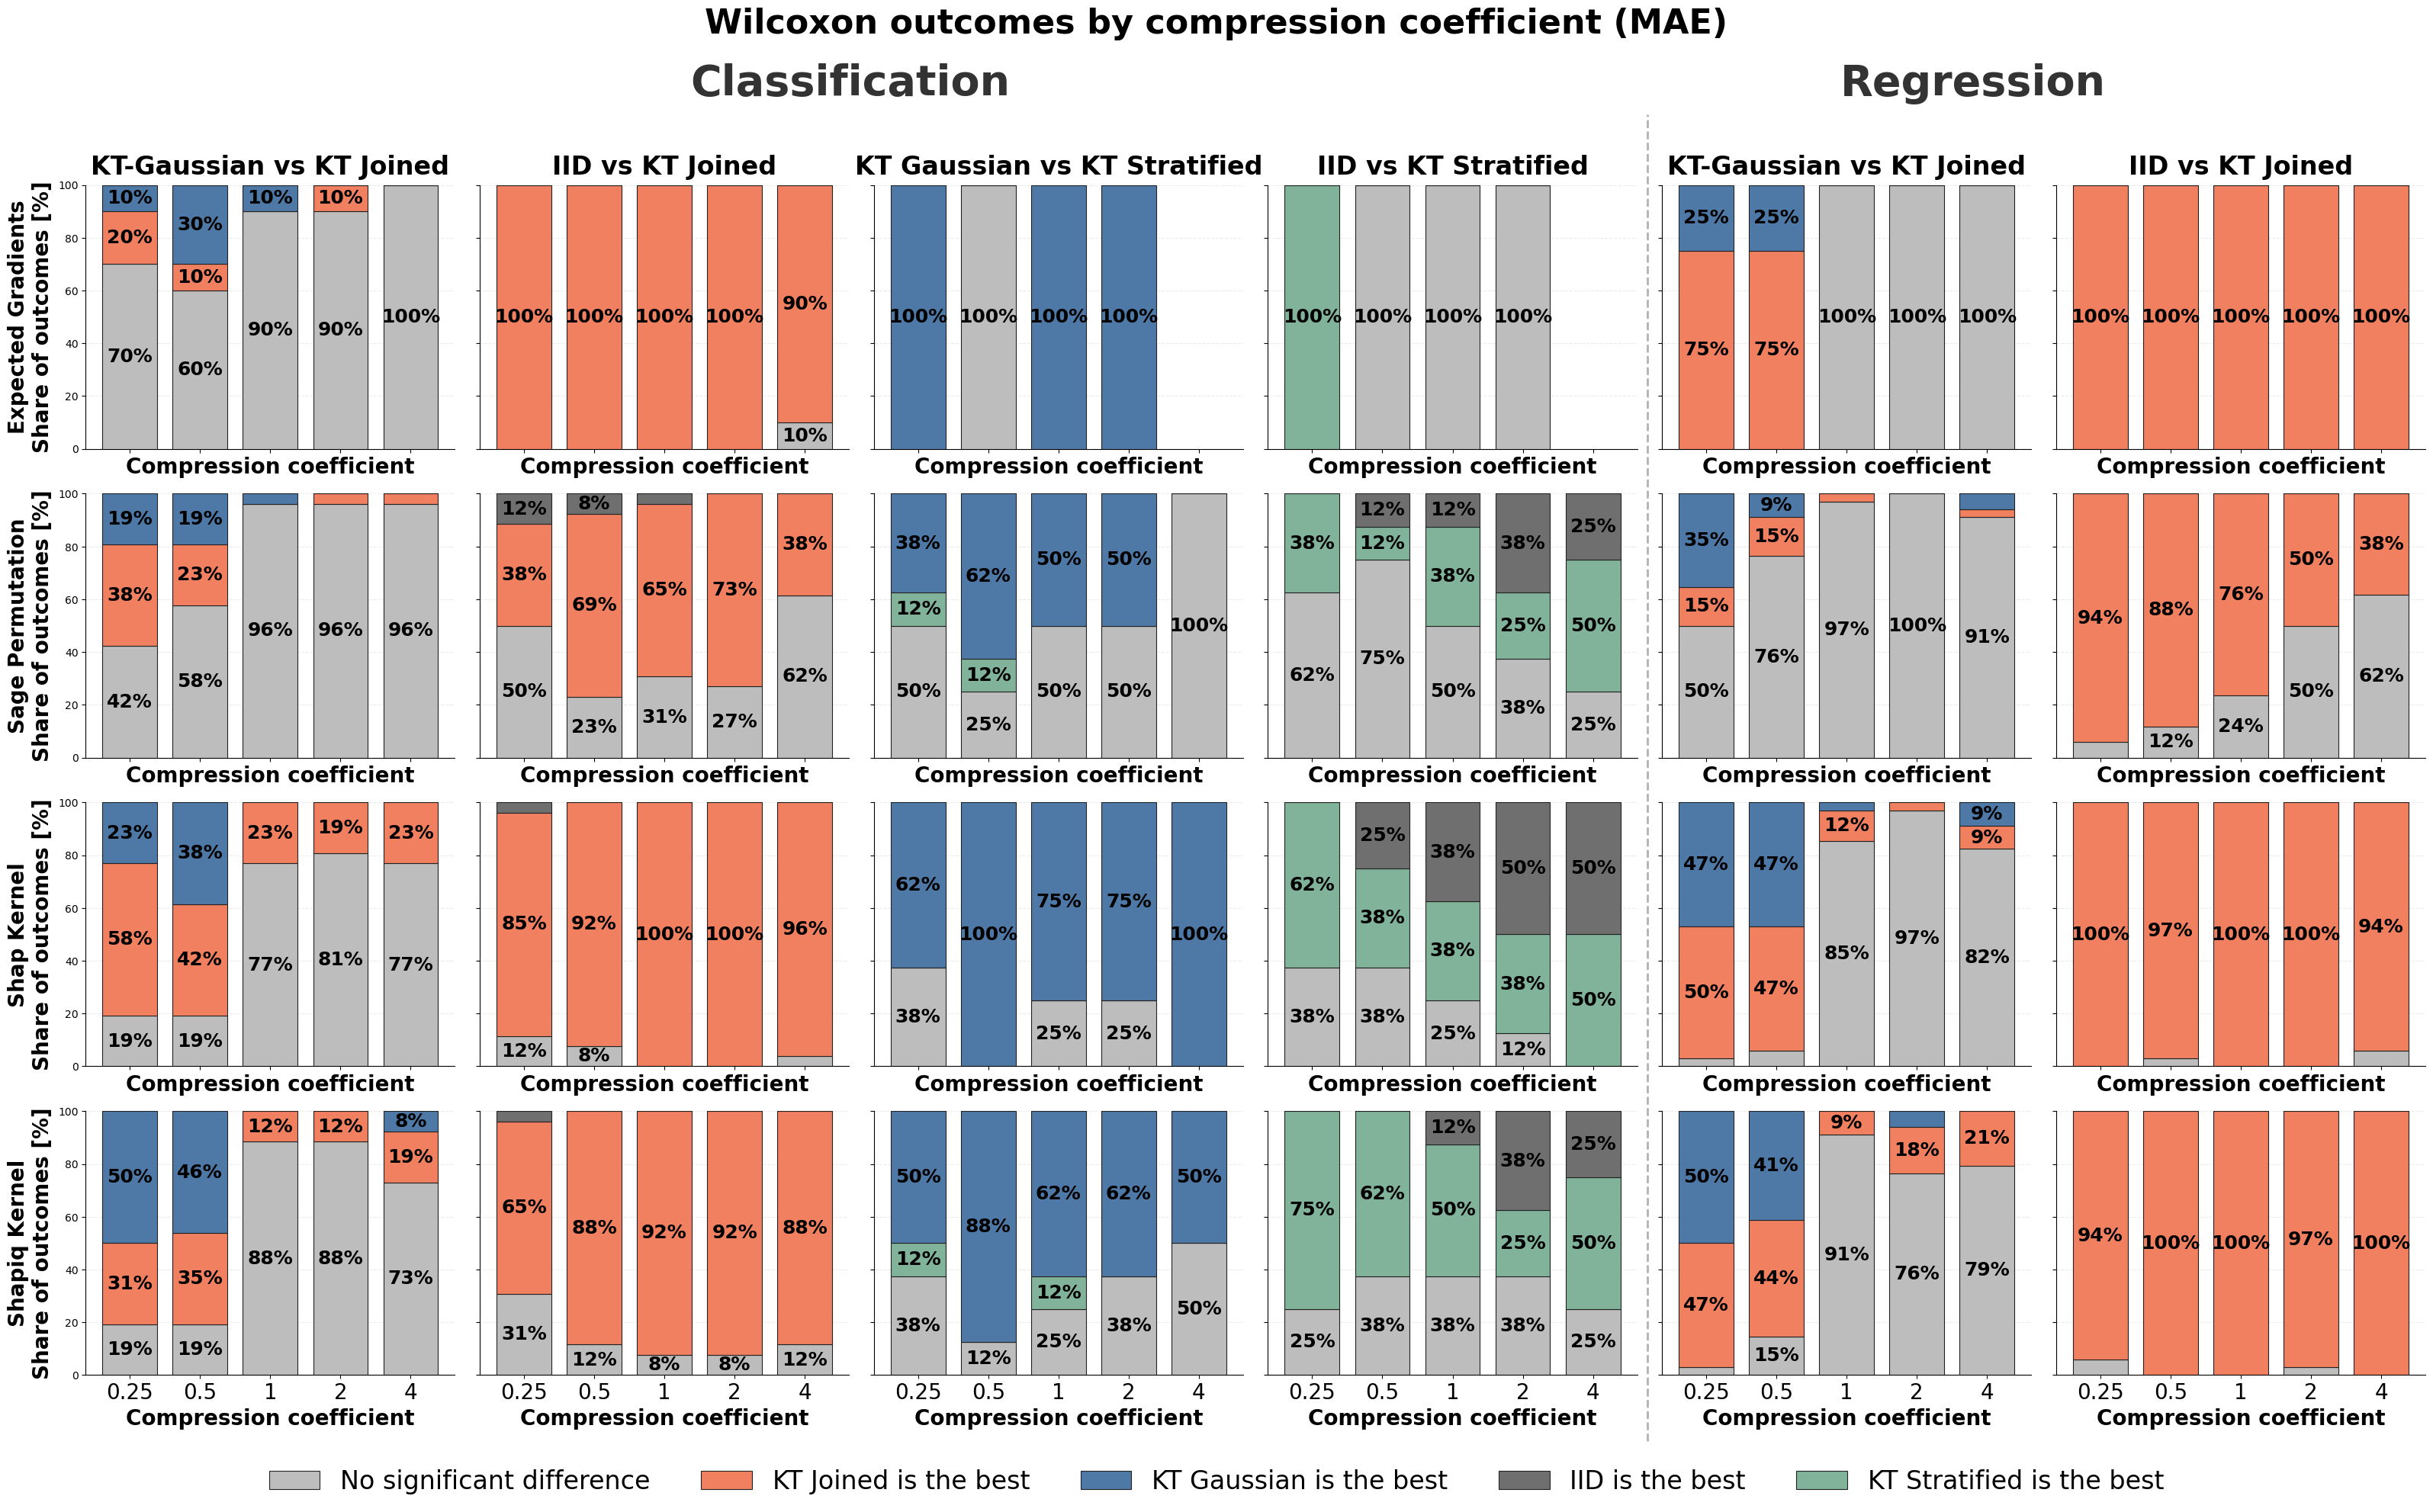

In [50]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_wilcoxon_stacked(
    table: pd.DataFrame,
    method_1: str,
    method_2: str,
    ax,
    title: str,
    colors: dict,
    labels_pretty: dict,
):
    df = table.copy()
    df["compression_coefficient"] = pd.to_numeric(df["compression_coefficient"], errors="coerce")
    df = df.dropna(subset=["compression_coefficient", "winner"])

    if df.empty:
        ax.set_axis_off()
        return

    cc_order = sorted(df["compression_coefficient"].unique())
    cc_labels = [f"{cc:g}" for cc in cc_order]

    winner_order = ["No significant difference", method_2, method_1]

    dist = (
        df.groupby(["compression_coefficient", "winner"])
          .size()
          .unstack(fill_value=0)
          .reindex(index=cc_order, columns=winner_order, fill_value=0)
    )

    pct = dist.div(dist.sum(axis=1), axis=0) * 100.0

    x = np.arange(len(cc_order))
    bottom = np.zeros(len(cc_order))

    for cat in winner_order:
        vals = pct[cat].values

        ax.bar(
            x,
            vals,
            bottom=bottom,
            width=0.78,
            color=colors[cat],
            edgecolor="#222222",
            linewidth=0.8,
            label=labels_pretty[cat],
            zorder=3,
        )

        for i, v in enumerate(vals):
            if v >= 6:
                ax.text(
                    x[i],
                    bottom[i] + v / 2,
                    f"{v:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=18,
                    fontweight="bold",
                    color="black",
                    zorder=4,
                )

        bottom += vals

    ax.set_ylim(0, 100)
    ax.set_xticks(x)
    ax.set_xticklabels(cc_labels, fontsize=20)
    ax.set_xlabel("Compression coefficient", fontsize=20, fontweight="bold")
    
    if title:
        ax.set_title(title, fontsize=24, fontweight="bold", pad=10)

    ax.grid(axis="y", linestyle="--", alpha=0.25, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


results = pd.read_csv("../package_metadata/results_all.csv")

comparisons_all = [
    ("kt_gaussian", "kt_predictions",
     {"No significant difference": "#BDBDBD", "kt_predictions": "#f08060", "kt_gaussian": "#4E79A7"},
     {"No significant difference": "No significant difference", "kt_predictions": "KT Joined is the best", "kt_gaussian": "KT Gaussian is the best"},
     "KT-Gaussian vs KT Joined"),

    ("iid", "kt_predictions",
     {"No significant difference": "#BDBDBD", "kt_predictions": "#f08060", "iid": "#6F6F6F"},
     {"No significant difference": "No significant difference", "kt_predictions": "KT Joined is the best", "iid": "IID is the best"},
     "IID vs KT Joined"),

    ("kt_gaussian", "kt_stratified",
     {"No significant difference": "#BDBDBD", "kt_stratified": "#81b29a", "kt_gaussian": "#4E79A7"},
     {"No significant difference": "No significant difference", "kt_stratified": "KT Stratified is the best", "kt_gaussian": "KT Gaussian is the best"},
     "KT Gaussian vs KT Stratified"),

     ("iid", "kt_stratified",
     {"No significant difference": "#BDBDBD", "kt_stratified": "#81b29a", "iid": "#6F6F6F"},
     {"No significant difference": "No significant difference", "kt_stratified": "KT Stratified is the best", "iid": "IID is the best"},
     "IID vs KT Stratified"),
]

comparisons_reg = [
    c for c in comparisons_all 
    if "kt_stratified" not in c[0] and "kt_stratified" not in c[1]
]

methods = sorted(results["explainer_total"].unique())
n_rows = len(methods)

n_cols_classif = len(comparisons_all)
n_cols_reg = len(comparisons_reg)
n_cols_total = n_cols_classif + n_cols_reg

fig, axes = plt.subplots(n_rows, n_cols_total, figsize=(32, 5 * n_rows), sharey=True, sharex=True)

if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

# -----------------------------
# MAIN LOOP
# -----------------------------
for i, method in enumerate(methods):
    results_cls = results[
        (results["explainer_total"] == method) & 
        (results["task"] == "classification")
    ]
    
    for j, (m1, m2, colors, labels_pretty, title) in enumerate(comparisons_all):
        ax = axes[i, j] 
        
        table = block_wilcoxon_table(results_cls, METRIC, m1, m2, alpha=ALPHA)
        
        plot_title = title if i == 0 else ""
        
        plot_wilcoxon_stacked(
            table=table, method_1=m1, method_2=m2, ax=ax,
            title=plot_title, colors=colors, labels_pretty=labels_pretty,
        )

        if j == 0:
            display_method = method.replace("_", " ").title()
            ax.set_ylabel(
                f"{display_method}\nShare of outcomes [%]", 
                fontsize=20, 
                fontweight="bold"
            )

    results_reg = results[
        (results["explainer_total"] == method) & 
        (results["task"] == "regression")
    ]
    
    for k, (m1, m2, colors, labels_pretty, title) in enumerate(comparisons_reg):
        col_idx = n_cols_classif + k 
        ax = axes[i, col_idx]
        
        table = block_wilcoxon_table(results_reg, METRIC, m1, m2, alpha=ALPHA)
        
        plot_title = title if i == 0 else ""
        
        plot_wilcoxon_stacked(
            table=table, method_1=m1, method_2=m2, ax=ax,
            title=plot_title, colors=colors, labels_pretty=labels_pretty,
        )

fig.text(0.35, 0.94, "Classification", ha="center", va="center", fontsize=40, fontweight="bold", color="#333333")
fig.text(0.81, 0.94, "Regression", ha="center", va="center", fontsize=40, fontweight="bold", color="#333333")

line_x = n_cols_classif / n_cols_total
line = plt.Line2D(
    [line_x + 0.01, line_x + 0.01],
    [0.05, 0.92], 
    transform=fig.transFigure, 
    color="black", 
    linestyle="--", 
    linewidth=2, 
    alpha=0.3
)
fig.add_artist(line)

handles_all, labels_all = [], []
for ax_row in axes:
    for ax in ax_row:
        if ax.axison: 
            h, l = ax.get_legend_handles_labels()
            handles_all.extend(h)
            labels_all.extend(l)

seen = {}
for h, l in zip(handles_all, labels_all):
    if l not in seen:
        seen[l] = h

fig.legend(
    seen.values(),
    seen.keys(),
    loc="lower center",
    ncol=len(seen),
    frameon=False,
    fontsize=24,
    bbox_to_anchor=(0.5, 0.0),
)

fig.suptitle(
    f"Wilcoxon outcomes by compression coefficient ({METRIC.upper()})",
    fontsize=32,
    fontweight="bold",
    y=0.99, 
)

plt.tight_layout(rect=[0, 0.05, 1, 0.93], w_pad=2.0)
os.makedirs("./image22", exist_ok=True)
plt.savefig("./image22/wilcoxon_compact_grid.pdf", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_13564/3638973458.py:84: DtypeWarning: Columns (30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  results = pd.read_csv("../package_metadata/results_all.csv")


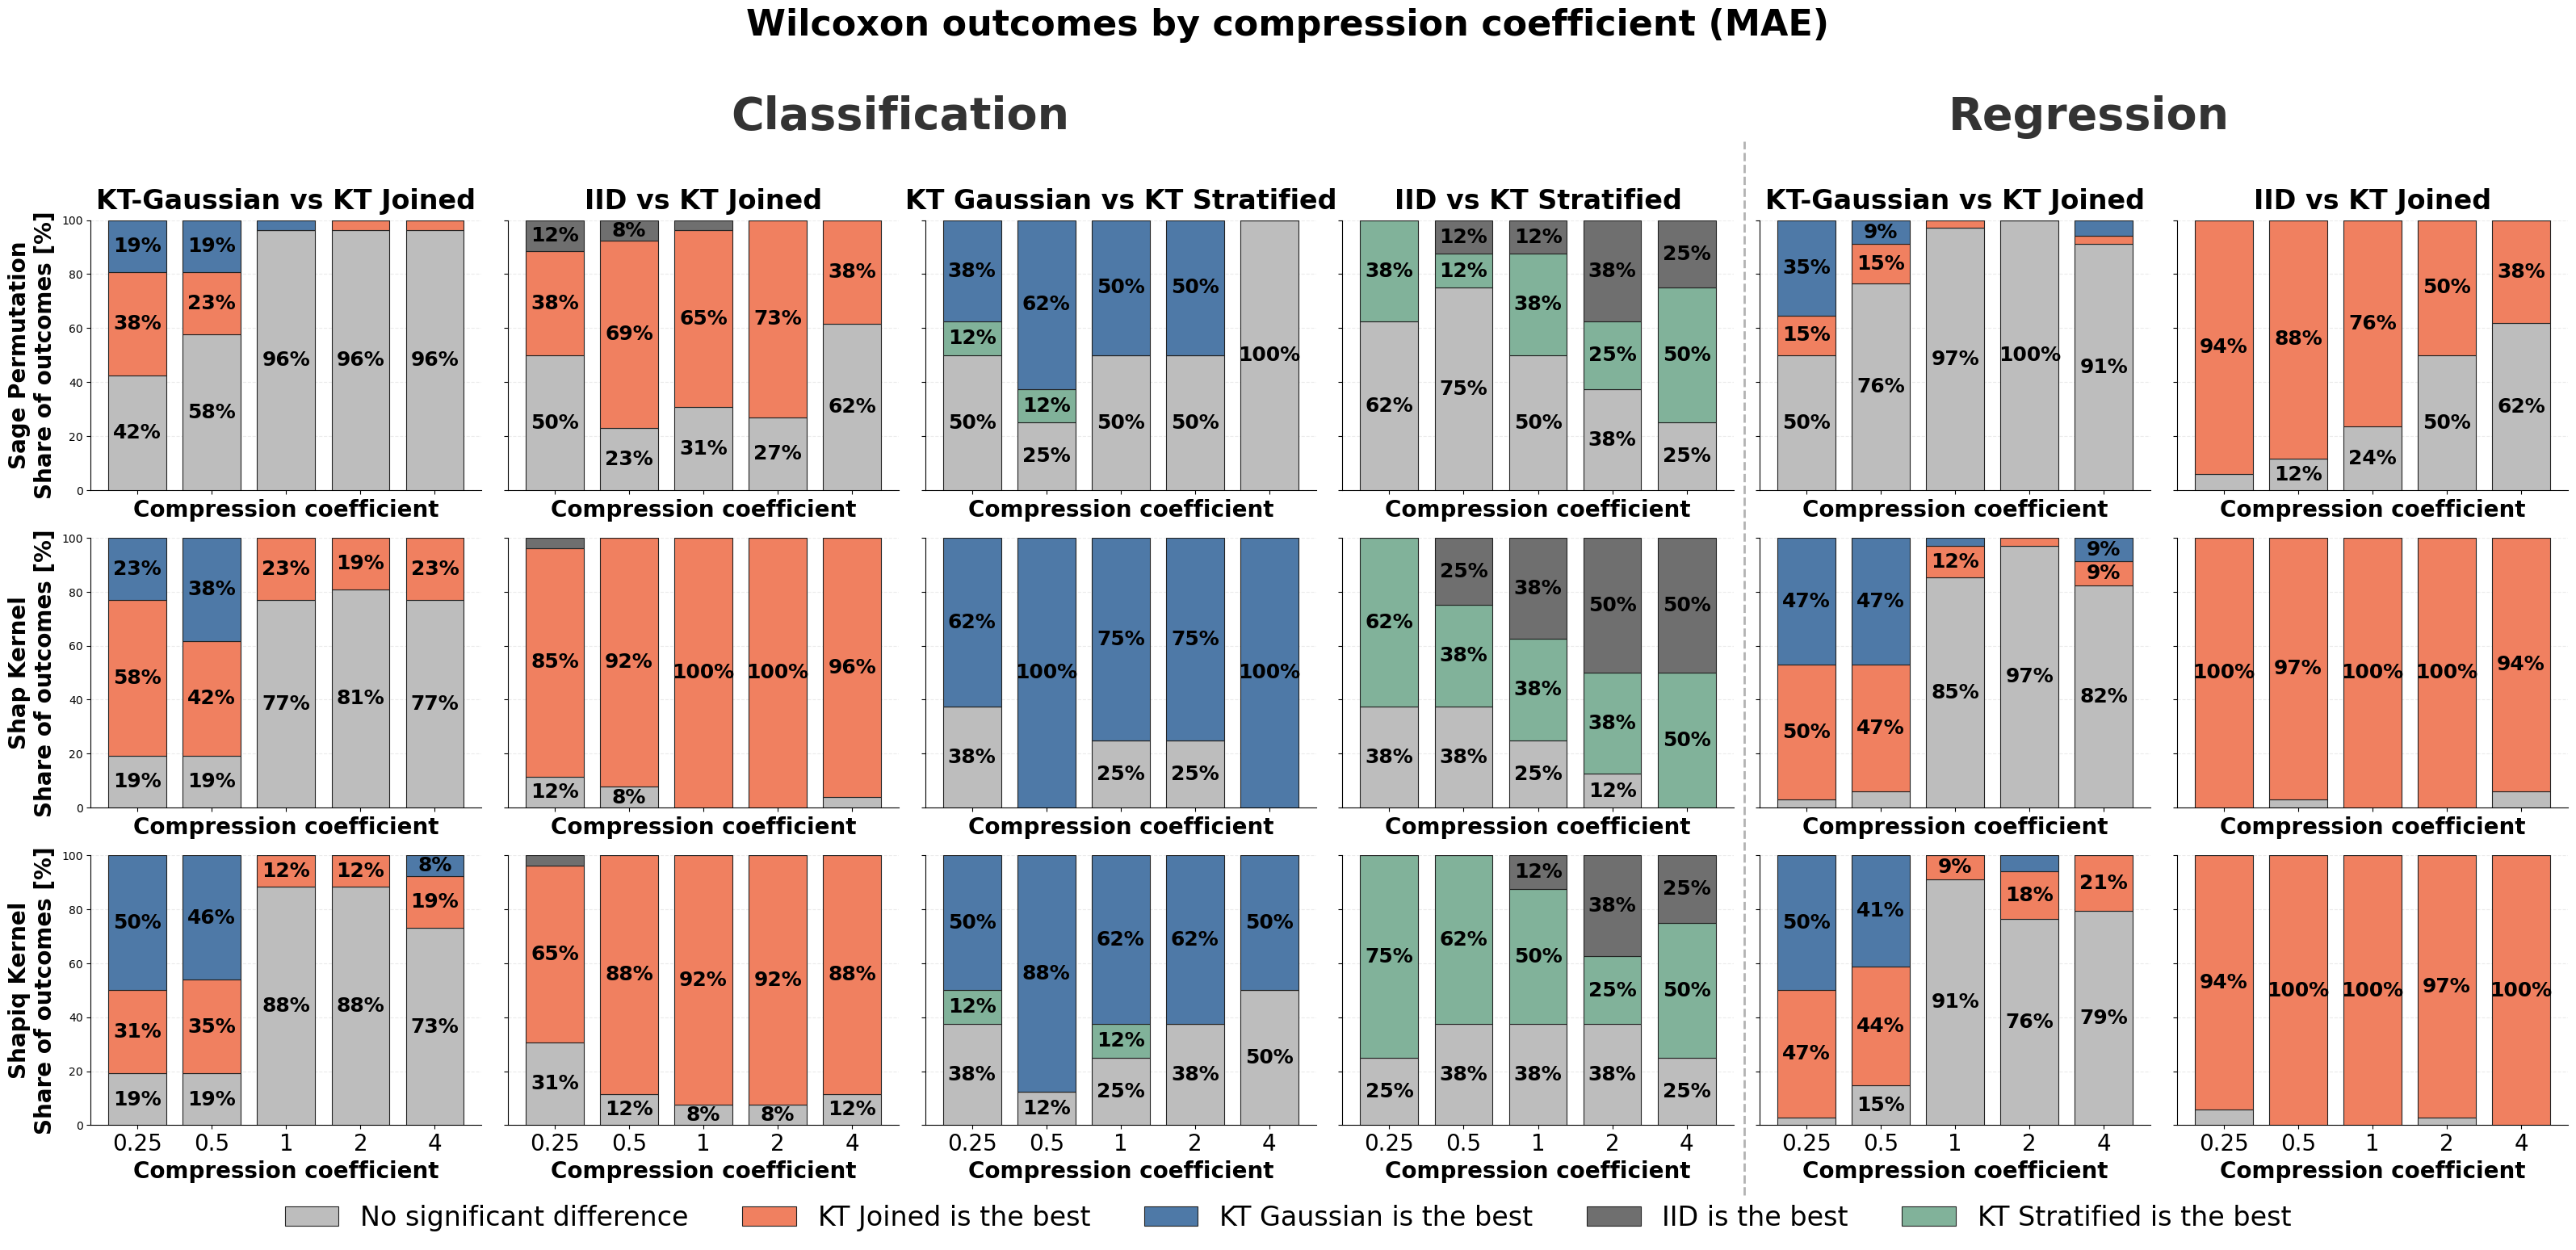

In [56]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_wilcoxon_stacked(
    table: pd.DataFrame,
    method_1: str,
    method_2: str,
    ax,
    title: str,
    colors: dict,
    labels_pretty: dict,
):
    df = table.copy()
    df["compression_coefficient"] = pd.to_numeric(df["compression_coefficient"], errors="coerce")
    df = df.dropna(subset=["compression_coefficient", "winner"])

    if df.empty:
        ax.set_axis_off()
        return

    cc_order = sorted(df["compression_coefficient"].unique())
    cc_labels = [f"{cc:g}" for cc in cc_order]

    winner_order = ["No significant difference", method_2, method_1]

    dist = (
        df.groupby(["compression_coefficient", "winner"])
          .size()
          .unstack(fill_value=0)
          .reindex(index=cc_order, columns=winner_order, fill_value=0)
    )

    pct = dist.div(dist.sum(axis=1), axis=0) * 100.0

    x = np.arange(len(cc_order))
    bottom = np.zeros(len(cc_order))

    for cat in winner_order:
        vals = pct[cat].values

        ax.bar(
            x,
            vals,
            bottom=bottom,
            width=0.78,
            color=colors[cat],
            edgecolor="#222222",
            linewidth=0.8,
            label=labels_pretty[cat],
            zorder=3,
        )

        for i, v in enumerate(vals):
            if v >= 6:
                ax.text(
                    x[i],
                    bottom[i] + v / 2,
                    f"{v:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=18,
                    fontweight="bold",
                    color="black",
                    zorder=4,
                )

        bottom += vals

    ax.set_ylim(0, 100)
    ax.set_xticks(x)
    ax.set_xticklabels(cc_labels, fontsize=20)
    ax.set_xlabel("Compression coefficient", fontsize=20, fontweight="bold")
    
    if title:
        ax.set_title(title, fontsize=24, fontweight="bold", pad=10)

    ax.grid(axis="y", linestyle="--", alpha=0.25, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


results = pd.read_csv("../package_metadata/results_all.csv")

comparisons_all = [
    ("kt_gaussian", "kt_predictions",
     {"No significant difference": "#BDBDBD", "kt_predictions": "#f08060", "kt_gaussian": "#4E79A7"},
     {"No significant difference": "No significant difference", "kt_predictions": "KT Joined is the best", "kt_gaussian": "KT Gaussian is the best"},
     "KT-Gaussian vs KT Joined"),

    ("iid", "kt_predictions",
     {"No significant difference": "#BDBDBD", "kt_predictions": "#f08060", "iid": "#6F6F6F"},
     {"No significant difference": "No significant difference", "kt_predictions": "KT Joined is the best", "iid": "IID is the best"},
     "IID vs KT Joined"),

    ("kt_gaussian", "kt_stratified",
     {"No significant difference": "#BDBDBD", "kt_stratified": "#81b29a", "kt_gaussian": "#4E79A7"},
     {"No significant difference": "No significant difference", "kt_stratified": "KT Stratified is the best", "kt_gaussian": "KT Gaussian is the best"},
     "KT Gaussian vs KT Stratified"),

     ("iid", "kt_stratified",
     {"No significant difference": "#BDBDBD", "kt_stratified": "#81b29a", "iid": "#6F6F6F"},
     {"No significant difference": "No significant difference", "kt_stratified": "KT Stratified is the best", "iid": "IID is the best"},
     "IID vs KT Stratified"),
]

comparisons_reg = [
    c for c in comparisons_all 
    if "kt_stratified" not in c[0] and "kt_stratified" not in c[1]
]

# methods = sorted(results["explainer_total"].unique())
methods = sorted(
    m for m in results["explainer_total"].unique()
    if "grad" not in str(m)
)
n_rows = len(methods)

n_cols_classif = len(comparisons_all)
n_cols_reg = len(comparisons_reg)
n_cols_total = n_cols_classif + n_cols_reg

fig, axes = plt.subplots(n_rows, n_cols_total, figsize=(32, 5 * n_rows), sharey=True, sharex=True)

if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

# -----------------------------
# MAIN LOOP
# -----------------------------
for i, method in enumerate(methods):
    results_cls = results[
        (results["explainer_total"] == method) & 
        (results["task"] == "classification")
    ]
    
    for j, (m1, m2, colors, labels_pretty, title) in enumerate(comparisons_all):
        ax = axes[i, j] 
        
        table = block_wilcoxon_table(results_cls, METRIC, m1, m2, alpha=ALPHA)
        
        plot_title = title if i == 0 else ""
        
        plot_wilcoxon_stacked(
            table=table, method_1=m1, method_2=m2, ax=ax,
            title=plot_title, colors=colors, labels_pretty=labels_pretty,
        )

        if j == 0:
            display_method = method.replace("_", " ").title()
            ax.set_ylabel(
                f"{display_method}\nShare of outcomes [%]", 
                fontsize=20, 
                fontweight="bold"
            )

    results_reg = results[
        (results["explainer_total"] == method) & 
        (results["task"] == "regression")
    ]
    
    for k, (m1, m2, colors, labels_pretty, title) in enumerate(comparisons_reg):
        col_idx = n_cols_classif + k 
        ax = axes[i, col_idx]
        
        table = block_wilcoxon_table(results_reg, METRIC, m1, m2, alpha=ALPHA)
        
        plot_title = title if i == 0 else ""
        
        plot_wilcoxon_stacked(
            table=table, method_1=m1, method_2=m2, ax=ax,
            title=plot_title, colors=colors, labels_pretty=labels_pretty,
        )

fig.text(0.35, 0.94, "Classification", ha="center", va="center", fontsize=40, fontweight="bold", color="#333333")
fig.text(0.81, 0.94, "Regression", ha="center", va="center", fontsize=40, fontweight="bold", color="#333333")

line_x = n_cols_classif / n_cols_total
line = plt.Line2D(
    [line_x + 0.01, line_x + 0.01],
    [0.05, 0.92], 
    transform=fig.transFigure, 
    color="black", 
    linestyle="--", 
    linewidth=2, 
    alpha=0.3
)
fig.add_artist(line)

handles_all, labels_all = [], []
for ax_row in axes:
    for ax in ax_row:
        if ax.axison: 
            h, l = ax.get_legend_handles_labels()
            handles_all.extend(h)
            labels_all.extend(l)

seen = {}
for h, l in zip(handles_all, labels_all):
    if l not in seen:
        seen[l] = h

fig.legend(
    seen.values(),
    seen.keys(),
    loc="lower center",
    ncol=len(seen),
    frameon=False,
    fontsize=24,
    bbox_to_anchor=(0.5, 0.0),
)

fig.suptitle(
    f"Wilcoxon outcomes by compression coefficient ({METRIC.upper()})",
    fontsize=32,
    fontweight="bold",
    y=1.03, 
)

plt.tight_layout(rect=[0, 0.05, 1, 0.93], w_pad=2.0)
os.makedirs("./image22", exist_ok=True)
plt.savefig("./image22/wilcoxon_compact_grid_without_EG.pdf", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_13564/912282096.py:84: DtypeWarning: Columns (30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  results = pd.read_csv("../package_metadata/results_all.csv")
/opt/anaconda3/envs/cte/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


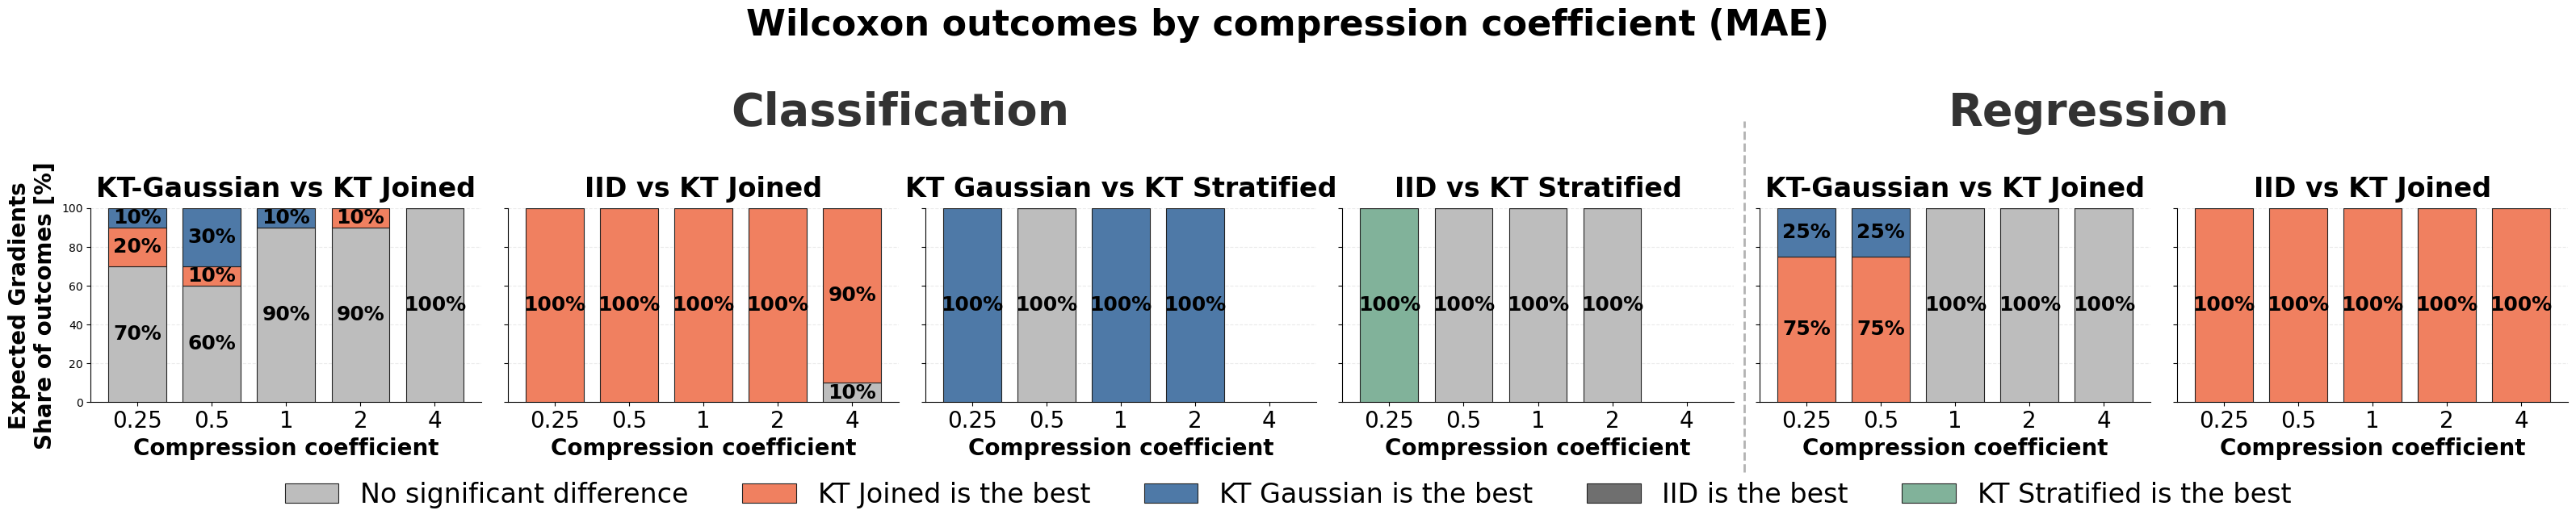

In [59]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_wilcoxon_stacked(
    table: pd.DataFrame,
    method_1: str,
    method_2: str,
    ax,
    title: str,
    colors: dict,
    labels_pretty: dict,
):
    df = table.copy()
    df["compression_coefficient"] = pd.to_numeric(df["compression_coefficient"], errors="coerce")
    df = df.dropna(subset=["compression_coefficient", "winner"])

    if df.empty:
        ax.set_axis_off()
        return

    cc_order = sorted(df["compression_coefficient"].unique())
    cc_labels = [f"{cc:g}" for cc in cc_order]

    winner_order = ["No significant difference", method_2, method_1]

    dist = (
        df.groupby(["compression_coefficient", "winner"])
          .size()
          .unstack(fill_value=0)
          .reindex(index=cc_order, columns=winner_order, fill_value=0)
    )

    pct = dist.div(dist.sum(axis=1), axis=0) * 100.0

    x = np.arange(len(cc_order))
    bottom = np.zeros(len(cc_order))

    for cat in winner_order:
        vals = pct[cat].values

        ax.bar(
            x,
            vals,
            bottom=bottom,
            width=0.78,
            color=colors[cat],
            edgecolor="#222222",
            linewidth=0.8,
            label=labels_pretty[cat],
            zorder=3,
        )

        for i, v in enumerate(vals):
            if v >= 6:
                ax.text(
                    x[i],
                    bottom[i] + v / 2,
                    f"{v:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=18,
                    fontweight="bold",
                    color="black",
                    zorder=4,
                )

        bottom += vals

    ax.set_ylim(0, 100)
    ax.set_xticks(x)
    ax.set_xticklabels(cc_labels, fontsize=20)
    ax.set_xlabel("Compression coefficient", fontsize=20, fontweight="bold")
    
    if title:
        ax.set_title(title, fontsize=24, fontweight="bold", pad=10)

    ax.grid(axis="y", linestyle="--", alpha=0.25, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


results = pd.read_csv("../package_metadata/results_all.csv")

comparisons_all = [
    ("kt_gaussian", "kt_predictions",
     {"No significant difference": "#BDBDBD", "kt_predictions": "#f08060", "kt_gaussian": "#4E79A7"},
     {"No significant difference": "No significant difference", "kt_predictions": "KT Joined is the best", "kt_gaussian": "KT Gaussian is the best"},
     "KT-Gaussian vs KT Joined"),

    ("iid", "kt_predictions",
     {"No significant difference": "#BDBDBD", "kt_predictions": "#f08060", "iid": "#6F6F6F"},
     {"No significant difference": "No significant difference", "kt_predictions": "KT Joined is the best", "iid": "IID is the best"},
     "IID vs KT Joined"),

    ("kt_gaussian", "kt_stratified",
     {"No significant difference": "#BDBDBD", "kt_stratified": "#81b29a", "kt_gaussian": "#4E79A7"},
     {"No significant difference": "No significant difference", "kt_stratified": "KT Stratified is the best", "kt_gaussian": "KT Gaussian is the best"},
     "KT Gaussian vs KT Stratified"),

     ("iid", "kt_stratified",
     {"No significant difference": "#BDBDBD", "kt_stratified": "#81b29a", "iid": "#6F6F6F"},
     {"No significant difference": "No significant difference", "kt_stratified": "KT Stratified is the best", "iid": "IID is the best"},
     "IID vs KT Stratified"),
]

comparisons_reg = [
    c for c in comparisons_all 
    if "kt_stratified" not in c[0] and "kt_stratified" not in c[1]
]

# methods = sorted(results["explainer_total"].unique())
methods = sorted(
    m for m in results["explainer_total"].unique()
    if "grad" in str(m)
)
n_rows = len(methods)

n_cols_classif = len(comparisons_all)
n_cols_reg = len(comparisons_reg)
n_cols_total = n_cols_classif + n_cols_reg

fig, axes = plt.subplots(n_rows, n_cols_total, figsize=(32, 5 * n_rows), sharey=True, sharex=True)

if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

# -----------------------------
# MAIN LOOP
# -----------------------------
for i, method in enumerate(methods):
    results_cls = results[
        (results["explainer_total"] == method) & 
        (results["task"] == "classification")
    ]
    
    for j, (m1, m2, colors, labels_pretty, title) in enumerate(comparisons_all):
        ax = axes[i, j] 
        
        table = block_wilcoxon_table(results_cls, METRIC, m1, m2, alpha=ALPHA)
        
        plot_title = title if i == 0 else ""
        
        plot_wilcoxon_stacked(
            table=table, method_1=m1, method_2=m2, ax=ax,
            title=plot_title, colors=colors, labels_pretty=labels_pretty,
        )

        if j == 0:
            display_method = method.replace("_", " ").title()
            ax.set_ylabel(
                f"{display_method}\nShare of outcomes [%]", 
                fontsize=20, 
                fontweight="bold"
            )

    results_reg = results[
        (results["explainer_total"] == method) & 
        (results["task"] == "regression")
    ]
    
    for k, (m1, m2, colors, labels_pretty, title) in enumerate(comparisons_reg):
        col_idx = n_cols_classif + k 
        ax = axes[i, col_idx]
        
        table = block_wilcoxon_table(results_reg, METRIC, m1, m2, alpha=ALPHA)
        
        plot_title = title if i == 0 else ""
        
        plot_wilcoxon_stacked(
            table=table, method_1=m1, method_2=m2, ax=ax,
            title=plot_title, colors=colors, labels_pretty=labels_pretty,
        )

fig.text(0.35, 0.94, "Classification", ha="center", va="center", fontsize=40, fontweight="bold", color="#333333")
fig.text(0.81, 0.94, "Regression", ha="center", va="center", fontsize=40, fontweight="bold", color="#333333")

line_x = n_cols_classif / n_cols_total
line = plt.Line2D(
    [line_x + 0.01, line_x + 0.01],
    [0.05, 0.92], 
    transform=fig.transFigure, 
    color="black", 
    linestyle="--", 
    linewidth=2, 
    alpha=0.3
)
fig.add_artist(line)

handles_all, labels_all = [], []
for ax_row in axes:
    for ax in ax_row:
        if ax.axison: 
            h, l = ax.get_legend_handles_labels()
            handles_all.extend(h)
            labels_all.extend(l)

seen = {}
for h, l in zip(handles_all, labels_all):
    if l not in seen:
        seen[l] = h

fig.legend(
    seen.values(),
    seen.keys(),
    loc="lower center",
    ncol=len(seen),
    frameon=False,
    fontsize=24,
    bbox_to_anchor=(0.5, -0.1),
)

fig.suptitle(
    f"Wilcoxon outcomes by compression coefficient ({METRIC.upper()})",
    fontsize=32,
    fontweight="bold",
    y=1.2, 
)

plt.tight_layout(rect=[0, 0.05, 1, 0.93], w_pad=2.0)
os.makedirs("./image22", exist_ok=True)
plt.savefig("./image22/wilcoxon_compact_grid_EG.pdf", dpi=300, bbox_inches="tight")
plt.show()